<a href="https://colab.research.google.com/github/pazvera/MechineLearning/blob/main/credit_card_fraud_detection_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de fraude con tarjetas de crédito mediante Machine Learning

### Aplicación y extensión del enfoque de Ileberi, Sun y Wang (2022)

**Integrantes:** Monserrat Vera y Khoen San Martín  
**Año:** 2026


## Resumen ejecutivo

Este proyecto estudia la detección de fraude con tarjetas de crédito como un problema de clasificación binaria **altamente desbalanceado**. Se utiliza el conjunto de datos público ULB/Worldline, compuesto por 284.807 transacciones y 492 fraudes.

El trabajo implementa y evalúa el enfoque desarrollado por Ileberi, Sun y Wang (2022). Se reproducen las principales etapas de preparación de datos y se emplean tres de los clasificadores analizados por los autores: Regresión Logística, Árbol de Decisión y Random Forest. Los vectores de variables `v1`–`v5`, obtenidos mediante algoritmo genético, se toman directamente del artículo.

Como extensión, se analiza el solapamiento asociado a filas duplicadas, se repite la evaluación después de eliminarlas y se incorpora XGBoost como modelo adicional. El desempeño se compara mediante Accuracy, Precision, Recall, Especificidad, F1-score, ROC-AUC, PR-AUC y matrices de confusión.


## 1. Contextualización

### 1.1 Pregunta de investigación

¿Puede un sistema que combina selección de variables mediante algoritmo genético y clasificadores supervisados mejorar la detección de fraude con tarjetas de crédito en una base altamente desbalanceada?

### 1.2 Metodología del estudio original

El artículo utiliza el conjunto de datos de transacciones de titulares europeos, aplica normalización Min–Max y SMOTE, selecciona cinco subconjuntos de atributos mediante un algoritmo genético y evalúa Decision Tree, Random Forest, Logistic Regression, Artificial Neural Network y Naive Bayes.

### 1.3 Resultado principal del paper

Los autores destacan la combinación GA–Random Forest con el vector `v5`. El estudio concluye que la selección de variables puede mejorar el desempeño de los clasificadores frente al uso de vectores completos o aleatorios.

### 1.4 Objetivo del presente trabajo

Implementar y evaluar el enfoque de detección de fraude propuesto en el artículo, comparar el desempeño de modelos supervisados y extender el análisis mediante XGBoost y una evaluación sin duplicados.

### 1.5 Decisiones metodológicas

- Se utiliza el conjunto de datos original.
- Se aplican los vectores `v1`–`v5` publicados.
- Se implementan tres modelos del paper y XGBoost como propuesta adicional.


## Organización del cuaderno

1. Resumen y contextualización del paper  
2. Datos y análisis exploratorio  
3. Preprocesamiento y diseño de evaluación  
4. Modelos representativos del paper y vectores GA  
5. Análisis de robustez sin filas duplicadas  
6. Modelo adicional: XGBoost  
7. Comparación de resultados  
8. Discusión, conclusiones y limitaciones  
9. Reproducibilidad y repositorio  
10. Referencias


## Preparación del entorno

Las siguientes celdas importan las bibliotecas necesarias y descargan el dataset. Las salidas se conservan en el notebook para facilitar su revisión, pero el archivo también debe poder ejecutarse desde una sesión limpia.


In [ ]:
import pandas as pd


In [ ]:
# Install dependencies as needed:
#!pip install kagglehub[pandas-datasets]

## 2. Datos y análisis exploratorio

### 2.1 Fuente y obtención

La base corresponde al dataset **Credit Card Fraud Detection** elaborado por ULB/Worldline y distribuido públicamente en Kaggle. Registra transacciones realizadas durante aproximadamente dos días de septiembre de 2013.

Las variables `V1`–`V28` están anonimizadas y corresponden a componentes transformados. `Time` mide los segundos transcurridos desde la primera observación, `Amount` registra el monto y `Class` es la variable objetivo: `1` indica fraude y `0` una transacción legítima.


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print(df.head())

/tmp/ipykernel_1065/1053364353.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 66.0M/66.0M [00:02<00:00, 25.2MB/s]

Extracting zip of creditcard.csv...


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### 2.2 Auditoría inicial de estructura y calidad

Se revisan dimensiones, nombres de columnas, tipos de datos, valores faltantes, estadísticas descriptivas y filas completamente duplicadas. Esta etapa permite documentar la calidad de la fuente antes de definir el flujo de modelamiento.


In [ ]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

df.info()

Dimensiones del dataset: (284807, 31)

Columnas:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     2848

In [ ]:
# Crear una copia de trabajo que conserva íntegramente la base descargada
df_raw = df.copy()


In [ ]:
# Visualizar los primeros cinco registros
# V1 a V28 corresponden a variables anonimizadas; Time, Amount y Class son observables.
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 284807
Número de columnas: 31


In [ ]:
# Visualizar nombres de las columnas
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
# Revisar estructura del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Contar valores faltantes por columna
df.isnull().sum()

total_null = df.isnull().sum().sum()

print(f"Total valores faltantes:{ total_null} ")

Total valores faltantes:0 


### 2.3 Filas duplicadas

Las filas completamente duplicadas se cuantifican y se examina su distribución por clase. En esta etapa no se eliminan definitivamente: primero se conserva la versión distribuida del conjunto de datos para la implementación inicial y, posteriormente, se desarrolla un análisis de robustez sin duplicados.


In [ ]:
# Contar filas duplicadas
df.duplicated().sum()

np.int64(1081)

In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Observar las primeras filas duplicadas
df[df.duplicated()].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [ ]:
# Contar duplicados según la clase de la transacción
df[df.duplicated()]["Class"].value_counts()

,count
Class,
0,1062
1,19


In [ ]:
# Conservar la base original y crear una versión preliminar sin duplicados
# únicamente para cuantificar su efecto descriptivo en esta etapa.

df_raw = df.copy()

df_clean_preview = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)


In [ ]:
# Verificar las dimensiones de ambas versiones

print("Dimensión original:", df_raw.shape)
print("Dimensión sin duplicados:", df_clean_preview.shape)
print(
    "Filas eliminadas:",
    df_raw.shape[0] - df_clean_preview.shape[0]
)


Dimensión original: (284807, 31)
Dimensión sin duplicados: (283726, 31)
Filas eliminadas: 1081


In [ ]:
print(
    "Duplicados en la base original:",
    df_raw.duplicated().sum()
)

print(
    "Duplicados en la versión preliminar sin duplicados:",
    df_clean_preview.duplicated().sum()
)


Duplicados en la base original: 1081
Duplicados en la versión preliminar sin duplicados: 0


In [ ]:
print("Distribución original:")
print(df_raw["Class"].value_counts())

print("\nDistribución sin duplicados:")
print(df_clean_preview["Class"].value_counts())


Distribución original:
Class
0    284315
1       492
Name: count, dtype: int64

Distribución sin duplicados:
Class
0    283253
1       473
Name: count, dtype: int64


### 2.4 Distribución de la variable objetivo

La principal dificultad estadística es el desbalance severo entre transacciones legítimas y fraudulentas. Debido a esta estructura, la Accuracy no puede interpretarse por sí sola: un modelo que predijera siempre “no fraude” alcanzaría una exactitud muy alta sin detectar operaciones fraudulentas.


In [ ]:
# Frecuencia absoluta de cada clase
frecuencia_clase = (
    df_raw["Class"]
    .value_counts()
    .sort_index()
)

# Porcentaje de cada clase
porcentaje_clase = (
    df_raw["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Crear tabla resumen
distribucion_clase = pd.DataFrame({
    "Frecuencia": frecuencia_clase,
    "% del total": porcentaje_clase
})

# Funciones de formato
def formato_entero(valor):
    return f"{valor:,.0f}".replace(",", ".")

def formato_porcentaje(valor):
    return f"{valor:.6f}".replace(".", ",") + "%"

# Mostrar la tabla sin modificar los datos originales
display(
    distribucion_clase.style.format({
        "Frecuencia": formato_entero,
        "% del total": formato_porcentaje
    })
)

,Frecuencia,% del total
Class,,
0,284.315,"99,827251%"
1,492,"0,172749%"


**Verificación:** la proporción de fraudes obtenida coincide con la magnitud reportada para el dataset utilizado por el paper.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

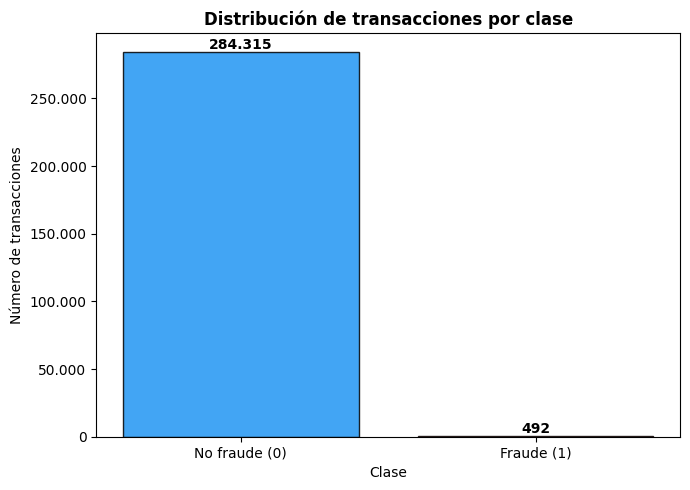

In [ ]:
# Visualizar la distribución de la variable objetivo

# Contar transacciones por clase
conteo_clase = df_raw["Class"].value_counts().sort_index()


# Crear la figura y el eje del gráfico

fig, ax = plt.subplots(figsize=(7, 5))

# Crear las barras

ax.bar(
    ["No fraude (0)", "Fraude (1)"],
    conteo_clase.values,
    color=["#2196F3", "#F44336"],
    edgecolor="black",
    alpha=0.85
)

# Títulos y nombres de ejes
ax.set_title(
    "Distribución de transacciones por clase",
    fontweight="bold"
)

ax.set_xlabel("Clase")
ax.set_ylabel("Número de transacciones")

# Separador de miles con punto en el eje vertical

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, posicion: f"{valor:,.0f}".replace(",", "."))
)

# Agregar frecuencia sobre cada barra
for posicion, valor in enumerate(conteo_clase.values):
    ax.text(
        posicion,
        valor,
        f"{valor:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


### 2.5 Variables directamente interpretables

Luego de la auditoría general y del análisis de la variable objetivo, se examinan `Amount` y `Time`, las dos variables cuyo significado no está anonimizado.


#### 2.5.1 Monto de la transacción (`Amount`)

Se comparan las estadísticas descriptivas y la forma de la distribución de los montos entre ambas clases. Los gráficos limitados al percentil 99 se utilizan exclusivamente para mejorar la lectura y no alteran la base empleada por los modelos.


In [ ]:
#Estadísticas descriptivas de Amount según la clase

resumen_amount = (
    df_raw
    .groupby("Class")["Amount"]
    .describe()
)
resumen_amount

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [ ]:
# Comparar la distribución de Amount según la clase

import seaborn as sns
import matplotlib.pyplot as plt


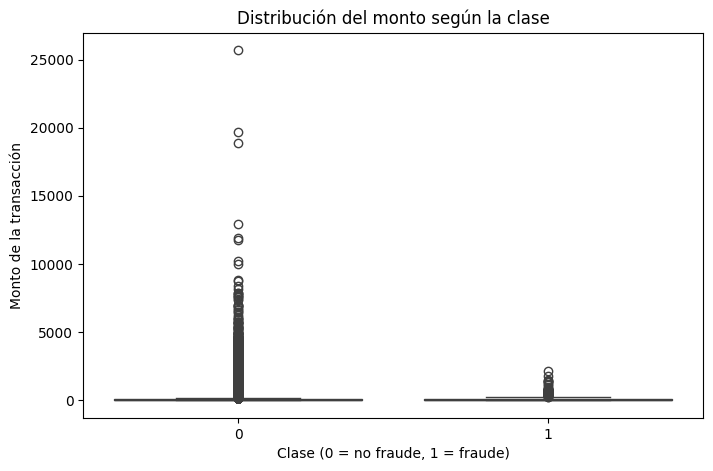

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_raw,
    x="Class",
    y="Amount"
)

plt.title("Distribución del monto según la clase")
plt.xlabel("Clase (0 = no fraude, 1 = fraude)")
plt.ylabel("Monto de la transacción")

plt.show()

### Distribución de los montos por clase

Debido a la presencia de valores extremos y al fuerte desbalance entre las clases, se utiliza un histograma normalizado y se limita la visualización al percentil 99 de `Amount`. Este ajuste afecta únicamente al gráfico y no modifica la base original.

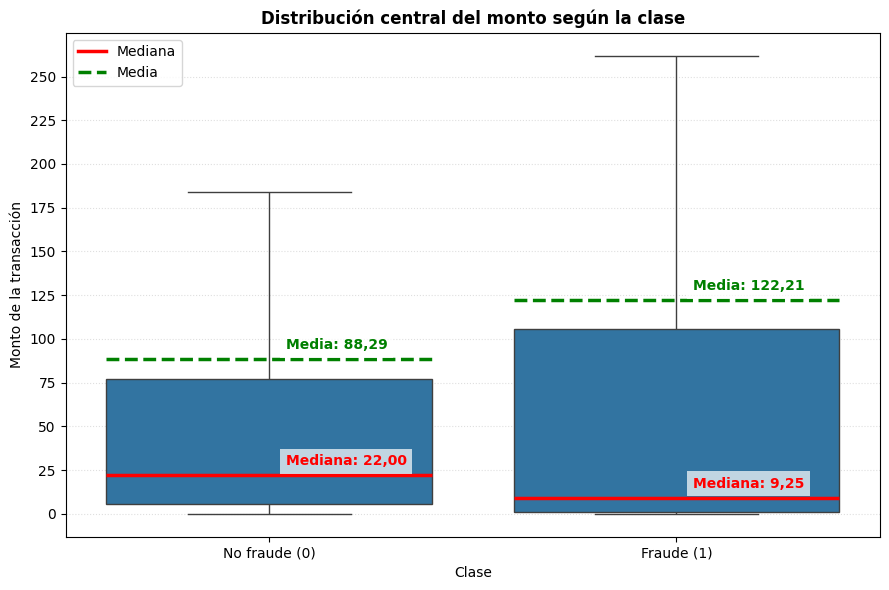

In [ ]:
# Comparar la distribución central de Amount según la clase

from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Calcular media y mediana por clase
media_amount = df_raw.groupby("Class")["Amount"].mean()
mediana_amount = df_raw.groupby("Class")["Amount"].median()

# Crear figura y eje
fig, ax = plt.subplots(figsize=(9, 6))

# Crear boxplot sin mostrar valores extremos
sns.boxplot(
    data=df_raw,
    x="Class",
    y="Amount",
    order=[0, 1],
    showfliers=False,
    showmeans=True,
    meanline=True,
    medianprops={
        "color": "red",
        "linewidth": 2.5
    },
    meanprops={
        "color": "green",
        "linestyle": "--",
        "linewidth": 2.5
    },
    ax=ax
)

# Título y nombres de ejes
ax.set_title(
    "Distribución central del monto según la clase",
    fontweight="bold"
)

ax.set_xlabel("Clase")
ax.set_ylabel("Monto de la transacción")

# Definir posiciones y etiquetas del eje horizontal
ax.set_xticks(
    [0, 1],
    ["No fraude (0)", "Fraude (1)"]
)

# Mostrar marcas cada 25 unidades
ax.yaxis.set_major_locator(
    MultipleLocator(25)
)

# Formatear números del eje vertical
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicion:
        f"{valor:,.0f}".replace(",", ".")
    )
)

# Agregar cuadrícula horizontal
ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

# Agregar valores exactos de media y mediana
for clase in [0, 1]:

    texto_media = (
        f"Media: {media_amount.loc[clase]:.2f}"
        .replace(".", ",")
    )

    texto_mediana = (
        f"Mediana: {mediana_amount.loc[clase]:.2f}"
        .replace(".", ",")
    )

    ax.text(
        clase + 0.04,
        media_amount.loc[clase] + 4,
        texto_media,
        color="green",
        va="bottom",
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "alpha": 0.7,
            "edgecolor": "none"
        }
    )

    ax.text(
        clase + 0.04,
        mediana_amount.loc[clase] + 4,
        texto_mediana,
        color="red",
        va="bottom",
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "alpha": 0.7,
            "edgecolor": "none"
        }
    )

# Crear leyenda
elementos_leyenda = [
    Line2D(
        [0], [0],
        color="red",
        linewidth=2.5,
        label="Mediana"
    ),
    Line2D(
        [0], [0],
        color="green",
        linestyle="--",
        linewidth=2.5,
        label="Media"
    )
]

ax.legend(
    handles=elementos_leyenda,
    loc="upper left"
)

plt.tight_layout()
plt.show()

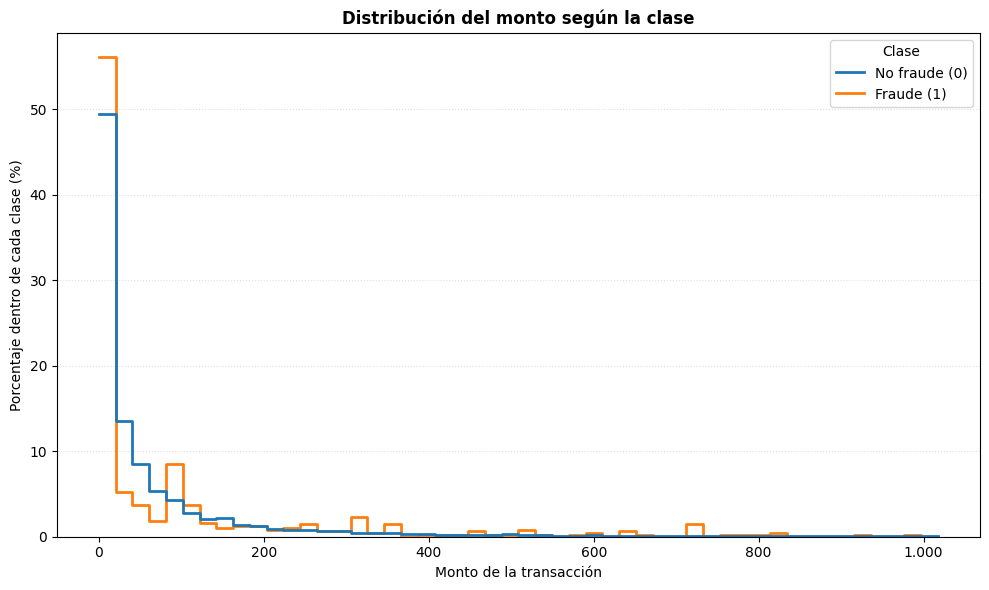

Percentil 99 de Amount: 1017.97


In [ ]:
# Histograma normalizado de Amount según la clase

# Calcular el percentil 99 de Amount
limite_amount = df_raw["Amount"].quantile(0.99)

# Crear una base temporal solo para la visualización
df_amount_grafico = (
    df_raw.loc[
        df_raw["Amount"] <= limite_amount,
        ["Amount", "Class"]
    ]
    .copy()
)

# Crear nombres interpretables para las clases
df_amount_grafico["Clase"] = (
    df_amount_grafico["Class"]
    .map({
        0: "No fraude (0)",
        1: "Fraude (1)"
    })
)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

# Crear histograma normalizado
sns.histplot(
    data=df_amount_grafico,
    x="Amount",
    hue="Clase",
    bins=50,
    stat="percent",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax
)

# Título y nombres de ejes
ax.set_title(
    "Distribución del monto según la clase",
    fontweight="bold"
)

ax.set_xlabel("Monto de la transacción")
ax.set_ylabel("Porcentaje dentro de cada clase (%)")

# Formatear eje horizontal
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicion:
        f"{valor:,.0f}".replace(",", ".")
    )
)

# Agregar cuadrícula
ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# Mostrar el límite utilizado
print(
    "Percentil 99 de Amount:",
    round(limite_amount, 2)
)

### Conclusión preliminar sobre `Amount`

Las transacciones fraudulentas presentan una mediana de monto inferior a las transacciones legítimas, lo que indica una mayor concentración de fraudes en montos bajos. Sin embargo, la media de los fraudes es superior debido a la presencia de algunas operaciones de mayor monto. Ambas distribuciones presentan asimetría hacia la derecha y valores extremos.

#### 2.5.2 Momento relativo de la transacción (`Time`)

`Time` no representa una fecha calendario ni una hora del día; corresponde al tiempo transcurrido desde la primera operación observada. Su análisis es exploratorio y debe interpretarse dentro del periodo reducido que cubre la base.


La variable `Time` representa los segundos transcurridos entre cada transacción y la primera transacción registrada en la base. No corresponde a la duración de la operación ni a una hora del día directamente observable.

Se analizará su distribución para determinar si las transacciones fraudulentas y legítimas presentan diferencias temporales dentro del periodo estudiado.


In [ ]:
# Estadísticas descriptivas de Time según la clase

resumen_time = (
    df_raw
    .groupby("Class")["Time"]
    .describe()
)


In [ ]:
# Convertir las estadísticas de Time desde segundos a horas

# Crear una copia de la tabla original
resumen_time_horas = resumen_time.copy()

# Columnas expresadas en unidades de tiempo
columnas_tiempo = [
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]

# Convertir segundos a horas
resumen_time_horas[columnas_tiempo] = (
    resumen_time_horas[columnas_tiempo] / 3600
)

resumen_time_horas

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,26.343945,13.190004,0.000000,15.063889,23.530833,38.703611,47.997778
1,492.0,22.429669,13.287601,0.112778,11.455972,20.991250,35.689722,47.318889


In [ ]:
# Crear una base temporal con Time expresado en horas

df_time = df_raw[["Time", "Class"]].copy()

df_time["Time_hours"] = (
    df_time["Time"] / 3600
)

df_time.head()


In [ ]:
# Identificar las transacciones ocurridas durante las primeras 24 horas

df_time["primeras_24_horas"] = (
    df_time["Time_hours"] <= 24
)

# Resumir por clase

resumen_24_horas = (
    df_time
    .groupby("Class")["primeras_24_horas"]
    .agg(["sum", "count", "mean"])
)

# Convertir la proporción a porcentaje

resumen_24_horas["porcentaje"] = (
    resumen_24_horas["mean"] * 100
)

resumen_24_horas

,sum,count,mean,porcentaje
Class,,,,
0,144506,284315,0.508260,50.826020
1,281,492,0.571138,57.113821


In [ ]:
# Identificar las transacciones ocurridas después de la hora 24

df_time["segundas_24_horas"] = (
    (df_time["Time_hours"] > 24)
    &
    (df_time["Time_hours"] <= 48)
)

# Resumir por clase

resumen_segundas_24_horas = (
    df_time
    .groupby("Class")["segundas_24_horas"]
    .agg(["sum", "count", "mean"])
)

# Convertir la proporción a porcentaje

resumen_segundas_24_horas["porcentaje"] = (
    resumen_segundas_24_horas["mean"] * 100
)

resumen_segundas_24_horas

,sum,count,mean,porcentaje
Class,,,,
0,139809,284315,0.491740,49.173980
1,211,492,0.428862,42.886179


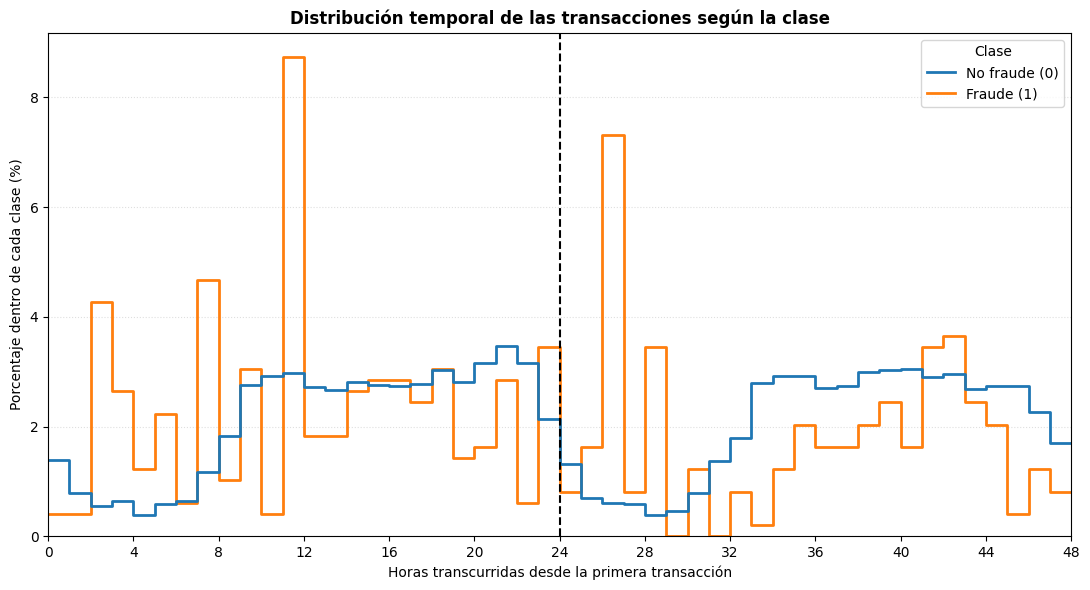

In [ ]:
# Crear una base temporal para el gráfico

df_time_grafico = df_time[
    ["Time_hours", "Class"]
].copy()

# Asignar nombres interpretables a las clases

df_time_grafico["Clase"] = (
    df_time_grafico["Class"]
    .map({
        0: "No fraude (0)",
        1: "Fraude (1)"
    })
)

# Crear gráfico

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    data=df_time_grafico,
    x="Time_hours",
    hue="Clase",
    bins=48,
    binrange=(0, 48),
    stat="percent",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax
)

# Marcar la separación entre las primeras y segundas 24 horas

ax.axvline(
    x=24,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Hora 24"
)

# Formato del gráfico

ax.set_title(
    "Distribución temporal de las transacciones según la clase",
    fontweight="bold"
)

ax.set_xlabel(
    "Horas transcurridas desde la primera transacción"
)

ax.set_ylabel(
    "Porcentaje dentro de cada clase (%)"
)

ax.set_xlim(0, 48)
ax.set_xticks(range(0, 49, 4))

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Conclusión preliminar sobre `Time`

La base registra aproximadamente 48 horas de transacciones. Las operaciones fraudulentas presentan una media y una mediana temporal algo menores que las transacciones legítimas, lo que sugiere una mayor concentración hacia las primeras horas del periodo.

Sin embargo, debido a que el registro cubre solamente dos días y no contiene información sobre fechas, horas reales ni ciclos semanales, este resultado debe interpretarse únicamente como un hallazgo exploratorio. No existe evidencia suficiente para establecer un patrón temporal generalizable.

### 2.6 Variables anonimizadas `V1`–`V28`

Las variables `V1` a `V28` corresponden a componentes transformados y anonimizados. El análisis que sigue busca describir su dispersión, asociación individual con la clase y capacidad exploratoria de separación, sin atribuirles una interpretación económica directa.


Se construye una lista programática con los nombres de los 28 componentes para evitar escribirlos manualmente y facilitar las operaciones posteriores.


In [ ]:
variables_v = [
    f"V{i}" for i in range(1, 29)
]

# Estadísticas descriptivas de las variables PCA

resumen_variables_v = (
    df_raw[variables_v]
    .describe()
    .T
)

resumen_variables_v



,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995
V10,284807.0,2.239053e-15,1.088850,-24.588262,-0.535426,-0.092917,0.453923,23.745136


In [ ]:
# Mostrar las 5 variables con mayor dispersión

variables_mayor_dispersion = (
    resumen_variables_v
    .sort_values(
        by="std",
        ascending=False
    )
    .head(5)
)

variables_mayor_dispersion

,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666


In [ ]:
# Comparar la media de V1 a V28 según la clase

medias_variables_v = (
    df_raw
    .groupby("Class")[variables_v]
    .mean()
    .T
)

# Cambiar nombres de las columnas

medias_variables_v.columns = [
    "Media_no_fraude",
    "Media_fraude"
]

# Calcular diferencia entre ambas clases

medias_variables_v["Diferencia"] = (
    medias_variables_v["Media_fraude"]
    -
    medias_variables_v["Media_no_fraude"]
)

# Calcular la magnitud de la diferencia

medias_variables_v["Diferencia_absoluta"] = (
    medias_variables_v["Diferencia"].abs()
)

# Ordenar desde la mayor diferencia hasta la menor

medias_variables_v = (
    medias_variables_v
    .sort_values(
        by="Diferencia_absoluta",
        ascending=False
    )
)

medias_variables_v.head(10)

,Media_no_fraude,Media_fraude,Diferencia,Diferencia_absoluta
V3,0.012171,-7.033281,-7.045452,7.045452
V14,0.012064,-6.971723,-6.983787,6.983787
V17,0.011535,-6.665836,-6.677371,6.677371
V12,0.010832,-6.259393,-6.270225,6.270225
V10,0.009824,-5.676883,-5.686707,5.686707
V7,0.009637,-5.568731,-5.578368,5.578368
V1,0.008258,-4.771948,-4.780206,4.780206
V4,-0.007860,4.542029,4.549889,4.549889
V16,0.007164,-4.139946,-4.147110,4.147110
V11,-0.006576,3.800173,3.806749,3.806749


In [ ]:
# Calcular media, desviación estándar y cantidad por clase

estadisticas_clase_v = (
    df_raw
    .groupby("Class")[variables_v]
    .agg(["mean", "std", "count"])
)

# Listas para guardar los resultados

resultados_diferencia_estandarizada = []

# Calcular la diferencia estandarizada para cada variable

for variable in variables_v:

    media_no_fraude = estadisticas_clase_v.loc[
        0, (variable, "mean")
    ]

    media_fraude = estadisticas_clase_v.loc[
        1, (variable, "mean")
    ]

    std_no_fraude = estadisticas_clase_v.loc[
        0, (variable, "std")
    ]

    std_fraude = estadisticas_clase_v.loc[
        1, (variable, "std")
    ]

    n_no_fraude = estadisticas_clase_v.loc[
        0, (variable, "count")
    ]

    n_fraude = estadisticas_clase_v.loc[
        1, (variable, "count")
    ]

    # Desviación estándar combinada de ambas clases

    std_combinada = (
        (
            (n_no_fraude - 1) * std_no_fraude**2
            +
            (n_fraude - 1) * std_fraude**2
        )
        /
        (n_no_fraude + n_fraude - 2)
    ) ** 0.5

    diferencia_estandarizada = (
        media_fraude - media_no_fraude
    ) / std_combinada

    resultados_diferencia_estandarizada.append({
        "Variable": variable,
        "Diferencia_estandarizada": diferencia_estandarizada,
        "Magnitud": abs(diferencia_estandarizada)
    })

# Convertir los resultados en DataFrame

diferencias_estandarizadas_v = pd.DataFrame(
    resultados_diferencia_estandarizada
)

# Ordenar desde la mayor separación hasta la menor

diferencias_estandarizadas_v = (
    diferencias_estandarizadas_v
    .sort_values(
        by="Magnitud",
        ascending=False
    )
)

diferencias_estandarizadas_v.head(10)

,Variable,Diferencia_estandarizada,Magnitud
16,V17,-8.317624,8.317624
13,V14,-7.643639,7.643639
11,V12,-6.499801,6.499801
9,V10,-5.350007,5.350007
15,V16,-4.826913,4.826913
2,V3,-4.735605,4.735605
6,V7,-4.590445,4.590445
10,V11,3.775043,3.775043
3,V4,3.242492,3.242492
17,V18,-2.701469,2.701469


In [ ]:
# Reiniciar el índice para mostrar un ranking ordenado

diferencias_estandarizadas_v = (
    diferencias_estandarizadas_v
    .reset_index(drop=True)
)

# Comenzar el ranking desde 1

diferencias_estandarizadas_v.index = (
    diferencias_estandarizadas_v.index + 1
)

diferencias_estandarizadas_v.index.name = "Ranking"

diferencias_estandarizadas_v.head(10)

,Variable,Diferencia_estandarizada,Magnitud
Ranking,,,
1,V17,-8.317624,8.317624
2,V14,-7.643639,7.643639
3,V12,-6.499801,6.499801
4,V10,-5.350007,5.350007
5,V16,-4.826913,4.826913
6,V3,-4.735605,4.735605
7,V7,-4.590445,4.590445
8,V11,3.775043,3.775043
9,V4,3.242492,3.242492


In [ ]:
# Estadísticas descriptivas de V17 según la clase

resumen_v17 = (
    df_raw
    .groupby("Class")["V17"]
    .describe()
)

resumen_v17

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,0.011535,0.749457,-17.098444,-0.482644,-0.064833,0.399922,9.253526
1,492.0,-6.665836,6.970618,-25.162799,-11.945057,-5.302949,-1.341940,6.739384


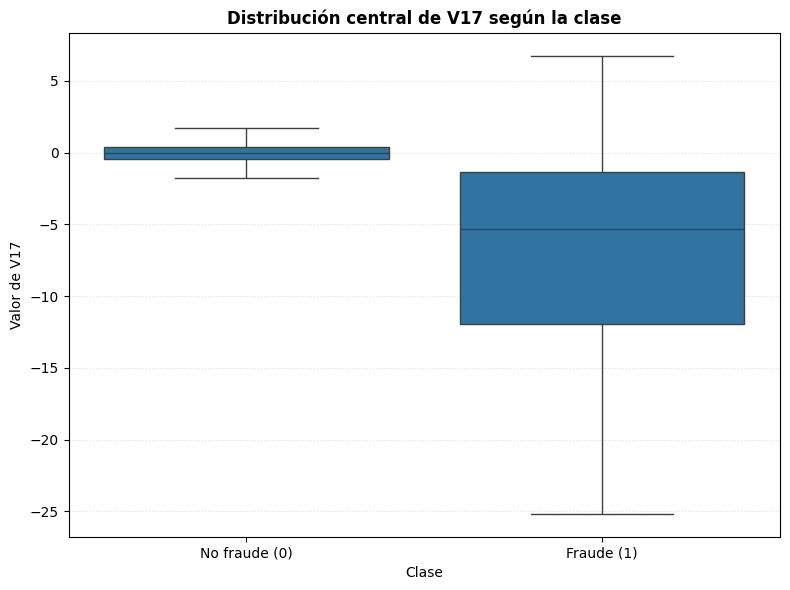

In [ ]:
# Distribución central de V17 según la clase

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df_raw,
    x="Class",
    y="V17",
    order=[0, 1],
    showfliers=False,
    ax=ax
)

ax.set_title(
    "Distribución central de V17 según la clase",
    fontweight="bold"
)

ax.set_xlabel("Clase")
ax.set_ylabel("Valor de V17")

ax.set_xticks(
    [0, 1],
    ["No fraude (0)", "Fraude (1)"]
)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

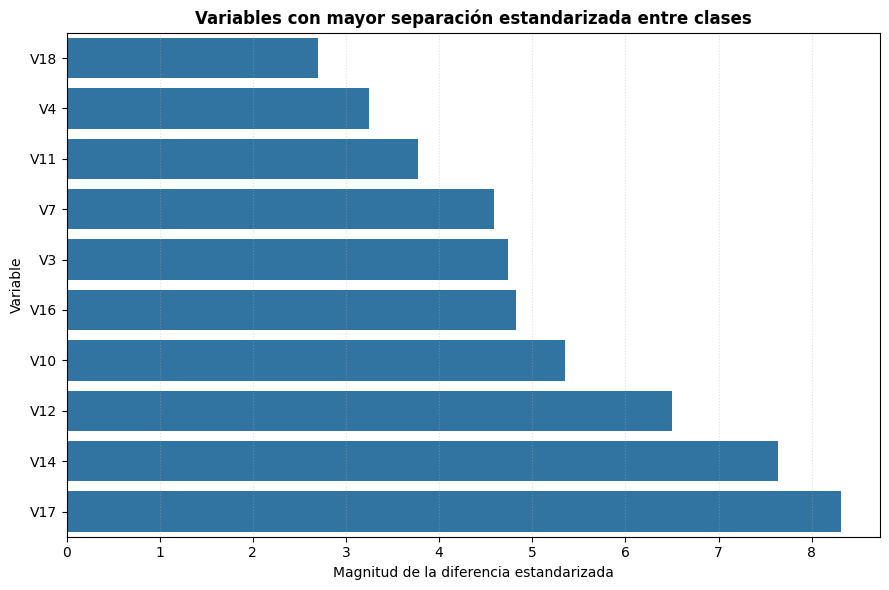

In [ ]:
# Seleccionar las 10 variables con mayor separación entre clases

top_10_variables = (
    diferencias_estandarizadas_v
    .head(10)
    .copy()
)

# Ordenarlas para construir el gráfico

top_10_variables = (
    top_10_variables
    .sort_values(
        by="Magnitud",
        ascending=True
    )
)

# Crear gráfico

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=top_10_variables,
    x="Magnitud",
    y="Variable",
    ax=ax
)

ax.set_title(
    "Variables con mayor separación estandarizada entre clases",
    fontweight="bold"
)

ax.set_xlabel(
    "Magnitud de la diferencia estandarizada"
)

ax.set_ylabel("Variable")

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
# Calcular la correlación de cada variable con Class

correlaciones_class = (
    df_raw
    .corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(
        key=abs,
        ascending=False
    )
)

correlaciones_class.head(15)

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


Los componentes V17, V14, V12, V10 y V16 presentan las mayores asociaciones individuales con la variable objetivo. La dirección negativa indica que los fraudes tienden a registrar valores inferiores en estos componentes. En contraste, V11 y V4 muestran asociaciones positivas. Debido a la anonimización mediante PCA, estos resultados tienen interpretación estadística y predictiva, pero no una interpretación económica directa.


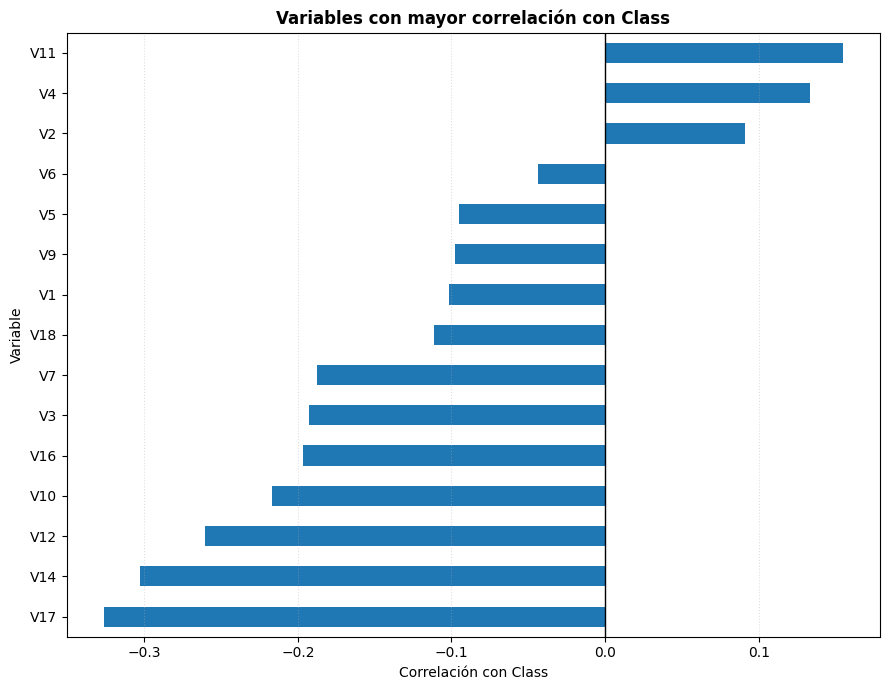

In [ ]:
# Seleccionar las 15 correlaciones de mayor magnitud

top_correlaciones = (
    correlaciones_class
    .head(15)
    .sort_values()
)

# Crear gráfico

fig, ax = plt.subplots(figsize=(9, 7))

top_correlaciones.plot(
    kind="barh",
    ax=ax
)

ax.axvline(
    x=0,
    color="black",
    linewidth=1
)

ax.set_title(
    "Variables con mayor correlación con Class",
    fontweight="bold"
)

ax.set_xlabel("Correlación con Class")
ax.set_ylabel("Variable")

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Conclusión preliminar sobre las variables PCA

El análisis exploratorio muestra que los componentes V17, V14, V12, V10 y V16 presentan las mayores asociaciones lineales negativas con la variable objetivo, por lo que los fraudes tienden a registrar valores inferiores en estos componentes. Por otra parte, V11, V4 y V2 presentan asociaciones positivas.

Estos resultados son consistentes con las diferencias estandarizadas observadas anteriormente. Sin embargo, las correlaciones representan asociaciones individuales y lineales, por lo que no determinan por sí solas la importancia predictiva final de cada variable. Además, debido a la anonimización mediante PCA, los componentes no poseen una interpretación económica directa.

## 3. Preprocesamiento y diseño de evaluación

### 3.1 Separación entrenamiento–prueba

La base se divide en 80 % para entrenamiento y 20 % para prueba utilizando estratificación, de modo que ambos conjuntos mantengan aproximadamente la proporción original de fraudes.

### 3.2 Prevención de contaminación del test

El escalador se ajusta exclusivamente con el entrenamiento. SMOTE también se aplica solo al entrenamiento, mientras que el conjunto de prueba conserva su distribución real. Esta secuencia evita que información del test participe en el aprendizaje de transformaciones o casos sintéticos.

### 3.3 Escalamiento y balanceo

Se utiliza Min–Max Scaling para llevar las variables a una escala común. Luego, SMOTE genera observaciones sintéticas de la clase minoritaria dentro del espacio de entrenamiento. El objetivo es reducir la tendencia de los clasificadores a ignorar los fraudes.


In [ ]:
# Separar variables explicativas y variable objetivo

X = df_raw.drop(
    columns="Class"
)

y = df_raw["Class"]

# Verificar dimensiones

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (284807, 30)
Dimensiones de y: (284807,)


In [ ]:
# Importar la función para dividir los datos

from sklearn.model_selection import train_test_split


# Dividir la base en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Mantener la proporción original de clases en ambos conjuntos
# Verificar dimensiones

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


In [ ]:
# Revisar la distribución de clases en entrenamiento y prueba

print("Distribución en entrenamiento:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Distribución en entrenamiento:
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Distribución en prueba:
Class
0    56864
1       98
Name: count, dtype: int64
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [ ]:
# Importar el escalador Min-Max

from sklearn.preprocessing import MinMaxScaler


# Crear el escalador

scaler = MinMaxScaler()


# Ajustar el escalador únicamente con los datos de entrenamiento

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)


# Aplicar al conjunto de prueba la transformación aprendida
# en el conjunto de entrenamiento

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# Verificar dimensiones

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (227845, 30)
X_test_scaled: (56962, 30)


In [ ]:
# Comparar algunas variables antes y después del escalamiento

print("Antes del escalamiento:")
display(
    X_train[
        ["Time", "Amount", "V1", "V17"]
    ].head()
)

print("Después del escalamiento:")
display(
    X_train_scaled[
        ["Time", "Amount", "V1", "V17"]
    ].head()
)

Antes del escalamiento:


,Time,Amount,V1,V17
265518,161919.0,7.32,1.946747,-0.765670
180305,124477.0,2.99,2.035149,-0.270842
42664,41191.0,175.10,-0.991920,-0.724616
198723,132624.0,6.10,2.285718,0.072781
82325,59359.0,86.10,-0.448747,-0.399525


Después del escalamiento:


,Time,Amount,V1,V17
265518,0.937075,0.000285,0.991418,0.708882
180305,0.720386,0.000116,0.992920,0.723260
42664,0.238385,0.006816,0.941491,0.710075
198723,0.767536,0.000237,0.997177,0.733244
82325,0.343529,0.003351,0.950719,0.719521


In [ ]:
# Importar SMOTE

from imblearn.over_sampling import SMOTE


# Crear el método SMOTE

smote = SMOTE(
    random_state=42
)


# Aplicar SMOTE únicamente al conjunto de entrenamiento escalado

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


# Verificar dimensiones antes y después

print("Antes de SMOTE:")
print("X_train_scaled:", X_train_scaled.shape)
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print(y_train_smote.value_counts())

Antes de SMOTE:
X_train_scaled: (227845, 30)
Class
0    227451
1       394
Name: count, dtype: int64

Después de SMOTE:
X_train_smote: (454902, 30)
Class
0    227451
1    227451
Name: count, dtype: int64


## 4. Modelos representativos del paper

El paper compara cinco clasificadores. Este trabajo utiliza un subconjunto representativo de tres:

- **Regresión Logística:** benchmark lineal e interpretable.
- **Árbol de Decisión:** modelo no lineal basado en reglas, útil también para estudiar sobreajuste.
- **Random Forest:** ensamble de árboles y modelo principal destacado por los autores.

### 4.1 Configuraciones principales

| Modelo | Configuración | Justificación |
|---|---|---|
| Regresión Logística | `max_iter=1000`, `random_state=42` | Permitir convergencia y asegurar reproducibilidad. |
| Árbol de Decisión | Sin poda, `random_state=42` | Construir un benchmark flexible y diagnosticar sobreajuste. |
| Random Forest | `n_estimators=100`, `random_state=42`, `n_jobs=-1` | Obtener un ensamble estable con un costo computacional razonable. |

Estas configuraciones son razonables y reproducibles; no se presentan como hiperparámetros globalmente óptimos.


### 4.2 Métricas de evaluación

- **Precision:** proporción de alertas de fraude que efectivamente eran fraude.
- **Recall:** proporción de fraudes reales correctamente detectados.
- **Especificidad:** proporción de transacciones legítimas correctamente clasificadas.
- **F1-score:** equilibrio armónico entre Precision y Recall.
- **ROC-AUC:** capacidad global de discriminación entre ambas clases.
- **PR-AUC:** desempeño de la relación Precision–Recall, especialmente informativo cuando la clase positiva es muy poco frecuente.

También se reportan `TN`, `FP`, `FN` y `TP` para interpretar directamente el costo operativo de los errores.


Se comienza con Regresión Logística, utilizada como modelo base interpretable y como uno de los clasificadores evaluados en el artículo.


In [ ]:
# Importar el modelo de regresión logística

from sklearn.linear_model import LogisticRegression


# Crear el modelo

modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Entrenar el modelo con los datos balanceados mediante SMOTE

modelo_logistico.fit(
    X_train_smote,
    y_train_smote
)

print("Modelo de regresión logística entrenado correctamente.")

Modelo de regresión logística entrenado correctamente.


In [ ]:
# Generar predicciones con la regresión logística

y_pred_logistico = modelo_logistico.predict(
    X_test_scaled
)

# Obtener la probabilidad estimada de fraude

y_prob_logistico = modelo_logistico.predict_proba(
    X_test_scaled
)[:, 1]

print("Cantidad de predicciones:", len(y_pred_logistico))
print("Primeras predicciones:", y_pred_logistico[:10])
print("Primeras probabilidades:", y_prob_logistico[:10])

Cantidad de predicciones: 56962
Primeras predicciones: [0 0 0 0 1 0 0 0 0 0]
Primeras probabilidades: [0.02476686 0.03752399 0.0762988  0.00920283 0.96397945 0.03096975
 0.00245498 0.02100824 0.09564739 0.00825942]


In [ ]:
# Importar métricas de clasificación

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# Calcular la matriz de confusión

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_logistico
).ravel()


# Crear tabla de métricas

metricas_logistico = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "Especificidad",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Resultado": [
        accuracy_score(y_test, y_pred_logistico),
        precision_score(y_test, y_pred_logistico),
        recall_score(y_test, y_pred_logistico),
        tn / (tn + fp),
        f1_score(y_test, y_pred_logistico),
        roc_auc_score(y_test, y_prob_logistico),
        average_precision_score(y_test, y_prob_logistico)
    ]
})

metricas_logistico

,Métrica,Resultado
0,Accuracy,0.976037
1,Precision,0.061592
2,Recall,0.908163
3,Especificidad,0.976154
4,F1-score,0.115360
5,ROC-AUC,0.974420
6,PR-AUC,0.718247


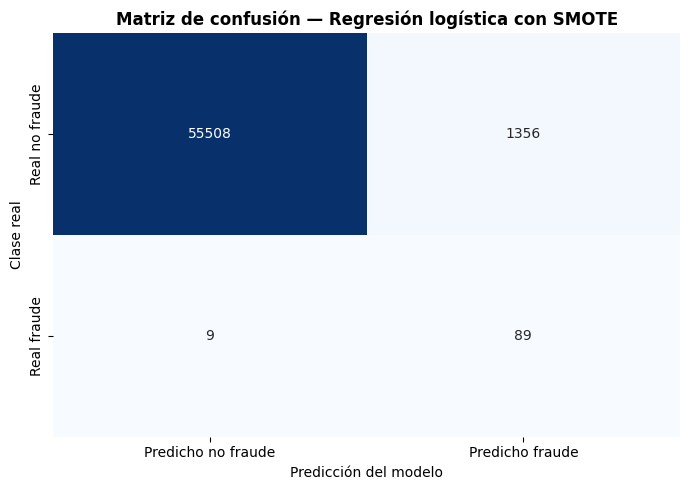

In [ ]:
# Crear la matriz de confusión

matriz_logistico = confusion_matrix(
    y_test,
    y_pred_logistico
)

# Crear gráfico

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    matriz_logistico,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicho no fraude",
        "Predicho fraude"
    ],
    yticklabels=[
        "Real no fraude",
        "Real fraude"
    ],
    ax=ax
)

ax.set_title(
    "Matriz de confusión — Regresión logística con SMOTE",
    fontweight="bold"
)

ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Clase real")

plt.tight_layout()
plt.show()

In [ ]:
# Guardar los resultados de la regresión logística

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión logística + SMOTE"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_logistico
        )
    ],
    "Precision": [
        precision_score(
            y_test,
            y_pred_logistico
        )
    ],
    "Recall": [
        recall_score(
            y_test,
            y_pred_logistico
        )
    ],
    "Especificidad": [
        tn / (tn + fp)
    ],
    "F1_score": [
        f1_score(
            y_test,
            y_pred_logistico
        )
    ],
    "ROC_AUC": [
        roc_auc_score(
            y_test,
            y_prob_logistico
        )
    ],
    "PR_AUC": [
        average_precision_score(
            y_test,
            y_prob_logistico
        )
    ],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

resultados_modelos

,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Regresión logística + SMOTE,0.976037,0.061592,0.908163,0.976154,0.11536,0.97442,0.718247,55508,1356,9,89


In [ ]:
# Importar el modelo de árbol de decisión

from sklearn.tree import DecisionTreeClassifier


# Crear el modelo

modelo_arbol = DecisionTreeClassifier(
    random_state=42
)


# Entrenar el árbol con los datos balanceados mediante SMOTE

modelo_arbol.fit(
    X_train_smote,
    y_train_smote
)

print("Árbol de decisión entrenado correctamente.")

Árbol de decisión entrenado correctamente.


In [ ]:
# Generar predicciones con el árbol de decisión

y_pred_arbol = modelo_arbol.predict(
    X_test_scaled
)

# Obtener la probabilidad estimada de fraude

y_prob_arbol = modelo_arbol.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "Cantidad de predicciones:",
    len(y_pred_arbol)
)

print(
    "Primeras predicciones:",
    y_pred_arbol[:10]
)

print(
    "Primeras probabilidades:",
    y_prob_arbol[:10]
)

Cantidad de predicciones: 56962
Primeras predicciones: [0 0 0 0 0 0 0 0 0 0]
Primeras probabilidades: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Contar las predicciones del árbol

pd.Series(
    y_pred_arbol
).value_counts().sort_index()

,count
0,56762
1,200


In [ ]:
# Calcular la matriz de confusión del árbol

tn_arbol, fp_arbol, fn_arbol, tp_arbol = confusion_matrix(
    y_test,
    y_pred_arbol
).ravel()


# Crear tabla de métricas del árbol

metricas_arbol = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "Especificidad",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Resultado": [
        accuracy_score(y_test, y_pred_arbol),
        precision_score(y_test, y_pred_arbol),
        recall_score(y_test, y_pred_arbol),
        tn_arbol / (tn_arbol + fp_arbol),
        f1_score(y_test, y_pred_arbol),
        roc_auc_score(y_test, y_prob_arbol),
        average_precision_score(y_test, y_prob_arbol)
    ]
})

metricas_arbol

,Métrica,Resultado
0,Accuracy,0.997367
1,Precision,0.370000
2,Recall,0.755102
3,Especificidad,0.997784
4,F1-score,0.496644
5,ROC-AUC,0.876443
6,PR-AUC,0.279809


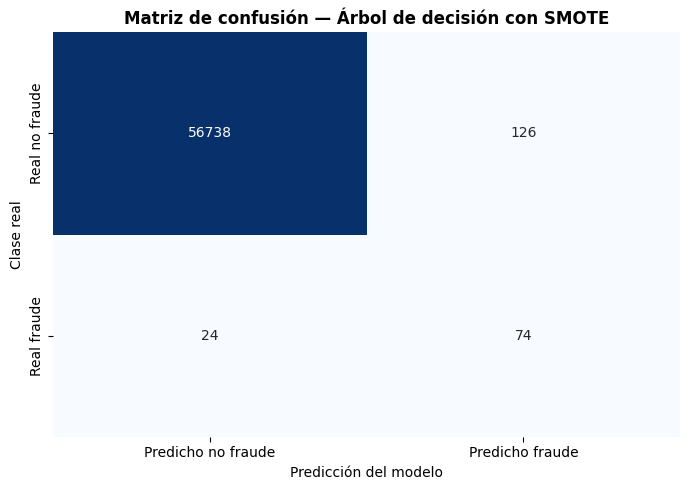

In [ ]:
# Crear la matriz de confusión del árbol

matriz_arbol = confusion_matrix(
    y_test,
    y_pred_arbol
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    matriz_arbol,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicho no fraude",
        "Predicho fraude"
    ],
    yticklabels=[
        "Real no fraude",
        "Real fraude"
    ],
    ax=ax
)

ax.set_title(
    "Matriz de confusión — Árbol de decisión con SMOTE",
    fontweight="bold"
)

ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Clase real")

plt.tight_layout()
plt.show()

In [ ]:
# Guardar los resultados del árbol de decisión

fila_arbol = pd.DataFrame({
    "Modelo": [
        "Árbol de decisión + SMOTE"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_arbol)
    ],
    "Precision": [
        precision_score(y_test, y_pred_arbol)
    ],
    "Recall": [
        recall_score(y_test, y_pred_arbol)
    ],
    "Especificidad": [
        tn_arbol / (tn_arbol + fp_arbol)
    ],
    "F1_score": [
        f1_score(y_test, y_pred_arbol)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_arbol)
    ],
    "PR_AUC": [
        average_precision_score(
            y_test,
            y_prob_arbol
        )
    ],
    "TN": [tn_arbol],
    "FP": [fp_arbol],
    "FN": [fn_arbol],
    "TP": [tp_arbol]
})

resultados_modelos = pd.concat(
    [
        resultados_modelos,
        fila_arbol
    ],
    ignore_index=True
)

resultados_modelos

,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Regresión logística + SMOTE,0.976037,0.061592,0.908163,0.976154,0.115360,0.974420,0.718247,55508,1356,9,89
1,Árbol de decisión + SMOTE,0.997367,0.370000,0.755102,0.997784,0.496644,0.876443,0.279809,56738,126,24,74


In [ ]:
# Verificar y ordenar la tabla comparativa actual

resultados_modelos = (
    resultados_modelos
    .drop_duplicates(
        subset="Modelo",
        keep="last"
    )
    .reset_index(drop=True)
)

resultados_modelos[
    [
        "Modelo",
        "Precision",
        "Recall",
        "F1_score",
        "FP",
        "FN",
        "TP"
    ]
]

,Modelo,Precision,Recall,F1_score,FP,FN,TP
0,Regresión logística + SMOTE,0.061592,0.908163,0.115360,1356,9,89
1,Árbol de decisión + SMOTE,0.370000,0.755102,0.496644,126,24,74


In [ ]:
# Importar Random Forest para clasificación

from sklearn.ensemble import RandomForestClassifier


# Instanciar el modelo

modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

# n_jobs=-1 permite utilizar todos los núcleos disponibles
# para reducir el tiempo de entrenamiento.

# Entrenar el modelo con el conjunto balanceado

modelo_random_forest.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest entrenado correctamente.")


Random Forest entrenado correctamente.


In [ ]:
# Predecir las clases del conjunto de prueba

y_pred_random_forest = modelo_random_forest.predict(
    X_test_scaled
)


# Obtener el puntaje o probabilidad estimada de fraude

y_prob_random_forest = modelo_random_forest.predict_proba(
    X_test_scaled
)[:, 1]


# Verificar resultados básicos

print("Cantidad de predicciones:", len(y_pred_random_forest))
print("\nPrimeras 10 clases predichas:")
print(y_pred_random_forest[:10])

print("\nPrimeras 10 probabilidades de fraude:")
print(y_prob_random_forest[:10])

Cantidad de predicciones: 56962

Primeras 10 clases predichas:
[0 0 0 0 0 0 0 0 0 0]

Primeras 10 probabilidades de fraude:
[0.   0.   0.02 0.   0.   0.   0.   0.   0.01 0.  ]


In [ ]:
# Contar las predicciones del Random Forest

conteo_predicciones_random_forest = (
    pd.Series(y_pred_random_forest)
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .sort_index()
)

conteo_predicciones_random_forest

,count
0,56866
1,96


In [ ]:
# Calcular matriz de confusión y métricas del Random Forest

tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(
    y_test,
    y_pred_random_forest
).ravel()


metricas_random_forest = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "Especificidad",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Resultado": [
        accuracy_score(
            y_test,
            y_pred_random_forest
        ),
        precision_score(
            y_test,
            y_pred_random_forest
        ),
        recall_score(
            y_test,
            y_pred_random_forest
        ),
        tn_rf / (tn_rf + fp_rf),
        f1_score(
            y_test,
            y_pred_random_forest
        ),
        roc_auc_score(
            y_test,
            y_prob_random_forest
        ),
        average_precision_score(
            y_test,
            y_prob_random_forest
        )
    ]
})

metricas_random_forest

,Métrica,Resultado
0,Accuracy,0.999473
1,Precision,0.854167
2,Recall,0.836735
3,Especificidad,0.999754
4,F1-score,0.845361
5,ROC-AUC,0.963667
6,PR-AUC,0.871521


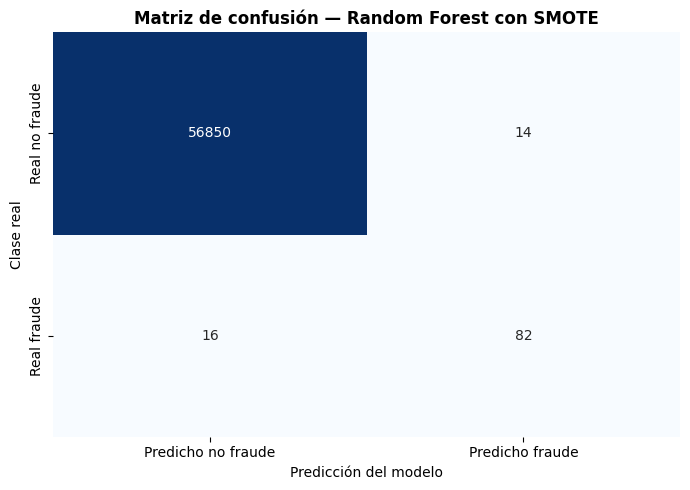

In [ ]:
# Matriz de confusión del Random Forest

matriz_random_forest = confusion_matrix(
    y_test,
    y_pred_random_forest
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    matriz_random_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicho no fraude",
        "Predicho fraude"
    ],
    yticklabels=[
        "Real no fraude",
        "Real fraude"
    ],
    ax=ax
)

ax.set_title(
    "Matriz de confusión — Random Forest con SMOTE",
    fontweight="bold"
)

ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Clase real")

plt.tight_layout()
plt.show()

In [ ]:
# Guardar los resultados de Random Forest

fila_random_forest = pd.DataFrame({
    "Modelo": [
        "Random Forest + SMOTE"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_random_forest
        )
    ],
    "Precision": [
        precision_score(
            y_test,
            y_pred_random_forest
        )
    ],
    "Recall": [
        recall_score(
            y_test,
            y_pred_random_forest
        )
    ],
    "Especificidad": [
        tn_rf / (tn_rf + fp_rf)
    ],
    "F1_score": [
        f1_score(
            y_test,
            y_pred_random_forest
        )
    ],
    "ROC_AUC": [
        roc_auc_score(
            y_test,
            y_prob_random_forest
        )
    ],
    "PR_AUC": [
        average_precision_score(
            y_test,
            y_prob_random_forest
        )
    ],
    "TN": [tn_rf],
    "FP": [fp_rf],
    "FN": [fn_rf],
    "TP": [tp_rf]
})


# Evitar duplicados si esta celda se ejecuta nuevamente

resultados_modelos = resultados_modelos[
    resultados_modelos["Modelo"]
    != "Random Forest + SMOTE"
]


# Agregar Random Forest a la tabla general

resultados_modelos = pd.concat(
    [
        resultados_modelos,
        fila_random_forest
    ],
    ignore_index=True
)


# Mostrar comparación principal

resultados_modelos[
    [
        "Modelo",
        "Precision",
        "Recall",
        "F1_score",
        "ROC_AUC",
        "PR_AUC",
        "FP",
        "FN",
        "TP"
    ]
]

,Modelo,Precision,Recall,F1_score,ROC_AUC,PR_AUC,FP,FN,TP
0,Regresión logística + SMOTE,0.061592,0.908163,0.115360,0.974420,0.718247,1356,9,89
1,Árbol de decisión + SMOTE,0.370000,0.755102,0.496644,0.876443,0.279809,126,24,74
2,Random Forest + SMOTE,0.854167,0.836735,0.845361,0.963667,0.871521,14,16,82


### 4.3 Selección de variables reportada por el algoritmo genético

Para evaluar el aporte de la selección de variables se utilizan los cinco vectores finales reportados por Ileberi, Sun y Wang (2022). El algoritmo genético no se vuelve a ejecutar; el análisis se concentra en comparar el desempeño de los subconjuntos publicados bajo una misma estrategia de entrenamiento y evaluación.


In [ ]:
# Vectores de variables seleccionados por el Genetic Algorithm del paper

vectores_ga_paper = {

    "v1": [
        "V1", "V5", "V7", "V8", "V11", "V13",
        "V14", "V15", "V16", "V17", "V18",
        "V19", "V20", "V21", "V22", "V23",
        "V24", "Amount"
    ],

    "v2": [
        "V1", "V6", "V13", "V16", "V17",
        "V22", "V23", "V28", "Amount"
    ],

    "v3": [
        "V2", "V11", "V12", "V13", "V15",
        "V16", "V17", "V18", "V20", "V21",
        "V24", "V26", "Amount"
    ],

    "v4": [
        "V2", "V7", "V10", "V13", "V15",
        "V17", "V19", "V28", "Amount"
    ],

    "v5": [
        "Time", "V1", "V7", "V8", "V9",
        "V11", "V12", "V14", "V15",
        "V22", "V27", "V28", "Amount"
    ]
}

In [ ]:
# Revisar cantidad de variables de cada vector

for nombre_vector, variables in vectores_ga_paper.items():
    print(
        nombre_vector,
        "→",
        len(variables),
        "variables"
    )

v1 → 18 variables
v2 → 9 variables
v3 → 13 variables
v4 → 9 variables
v5 → 13 variables


In [ ]:
# Verificar los vectores seleccionados por el Genetic Algorithm

for nombre_vector, variables in vectores_ga_paper.items():

    variables_faltantes = [
        variable
        for variable in variables
        if variable not in X_train.columns
    ]

    variables_repetidas = (
        len(variables)
        != len(set(variables))
    )

    print(
        f"{nombre_vector}: "
        f"{len(variables)} variables | "
        f"Faltantes: {variables_faltantes} | "
        f"Repetidas: {variables_repetidas}"
    )

v1: 18 variables | Faltantes: [] | Repetidas: False
v2: 9 variables | Faltantes: [] | Repetidas: False
v3: 13 variables | Faltantes: [] | Repetidas: False
v4: 9 variables | Faltantes: [] | Repetidas: False
v5: 13 variables | Faltantes: [] | Repetidas: False


### 4.4 Verificación manual con el vector `v1`

Antes de automatizar los demás vectores, el flujo completo se ejecuta manualmente con `v1`: selección de columnas, SMOTE en entrenamiento, ajuste de cada modelo, predicciones, matrices de confusión y métricas.


In [ ]:
# Seleccionar las variables del vector v1

variables_v1 = vectores_ga_paper["v1"]


# Construir los conjuntos de entrenamiento y prueba usando solo v1

X_train_v1 = X_train_scaled.loc[
    :,
    variables_v1
].copy()

X_test_v1 = X_test_scaled.loc[
    :,
    variables_v1
].copy()


# Verificar las dimensiones y las variables seleccionadas

print("Variables de v1:")
print(variables_v1)

print("\nCantidad de variables:", len(variables_v1))

print("\nDimensiones:")
print("X_train_v1:", X_train_v1.shape)
print("X_test_v1:", X_test_v1.shape)

print("\nColumnas de X_train_v1:")
print(X_train_v1.columns.tolist())

Variables de v1:
['V1', 'V5', 'V7', 'V8', 'V11', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'Amount']

Cantidad de variables: 18

Dimensiones:
X_train_v1: (227845, 18)
X_test_v1: (56962, 18)

Columnas de X_train_v1:
['V1', 'V5', 'V7', 'V8', 'V11', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'Amount']


In [ ]:
# Aplicar SMOTE al conjunto de entrenamiento de v1

smote_v1 = SMOTE(
    random_state=42
)

X_train_v1_smote, y_train_v1_smote = smote_v1.fit_resample(
    X_train_v1,
    y_train
)


# Mantener nombres de columnas y variable objetivo

X_train_v1_smote = pd.DataFrame(
    X_train_v1_smote,
    columns=variables_v1
)

y_train_v1_smote = pd.Series(
    y_train_v1_smote,
    name="Class"
)


# Verificar dimensiones y distribución de clases

print("Antes de SMOTE:")
print("X_train_v1:", X_train_v1.shape)
print(y_train.value_counts().sort_index())

print("\nDespués de SMOTE:")
print("X_train_v1_smote:", X_train_v1_smote.shape)
print(y_train_v1_smote.value_counts().sort_index())

print("\nConjunto de prueba sin modificar:")
print("X_test_v1:", X_test_v1.shape)
print(y_test.value_counts().sort_index())

Antes de SMOTE:
X_train_v1: (227845, 18)
Class
0    227451
1       394
Name: count, dtype: int64

Después de SMOTE:
X_train_v1_smote: (454902, 18)
Class
0    227451
1    227451
Name: count, dtype: int64

Conjunto de prueba sin modificar:
X_test_v1: (56962, 18)
Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:
# Entrenar Random Forest con el vector v1

from sklearn.ensemble import RandomForestClassifier


random_forest_v1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# El modelo recibe únicamente el entrenamiento balanceado de v1.
# El conjunto de prueba permanece reservado para la evaluación fuera de muestra.

random_forest_v1.fit(
    X_train_v1_smote,
    y_train_v1_smote
)


print("Random Forest con v1 entrenado correctamente.")

print(
    "Cantidad de variables utilizadas:",
    random_forest_v1.n_features_in_
)

print(
    "Cantidad de árboles entrenados:",
    len(random_forest_v1.estimators_)
)


Random Forest con v1 entrenado correctamente.
Cantidad de variables utilizadas: 18
Cantidad de árboles entrenados: 100


In [ ]:
# Generar predicciones con Random Forest usando v1

y_pred_random_forest_v1 = random_forest_v1.predict(
    X_test_v1
)

y_prob_random_forest_v1 = random_forest_v1.predict_proba(
    X_test_v1
)[:, 1]


# Verificar las salidas

print(
    "Cantidad de predicciones:",
    len(y_pred_random_forest_v1)
)

print("\nPrimeras 10 clases predichas:")
print(
    y_pred_random_forest_v1[:10]
)

print("\nPrimeras 10 probabilidades de fraude:")
print(
    y_prob_random_forest_v1[:10]
)

print("\nDistribución de clases predichas:")
print(
    pd.Series(
        y_pred_random_forest_v1
    ).value_counts().sort_index()
)

Cantidad de predicciones: 56962

Primeras 10 clases predichas:
[0 0 0 0 0 0 0 0 0 0]

Primeras 10 probabilidades de fraude:
[0.   0.02 0.03 0.   0.   0.   0.   0.   0.   0.  ]

Distribución de clases predichas:
0    56860
1      102
Name: count, dtype: int64


In [ ]:
# Crear una tabla con los resultados de las predicciones de Random Forest + v1

tabla_predicciones_v1 = pd.DataFrame(
    {
        "Clase_real": y_test.loc[X_test_v1.index].to_numpy(),
        "Clase_predicha": y_pred_random_forest_v1,
        "Probabilidad_fraude": y_prob_random_forest_v1
    },
    index=X_test_v1.index
)

tabla_predicciones_v1.index.name = "Indice_transaccion"


# Mostrar únicamente las transacciones predichas como fraude

alertas_fraude_v1 = tabla_predicciones_v1[
    tabla_predicciones_v1["Clase_predicha"] == 1
].copy()

print("Cantidad de alertas:", len(alertas_fraude_v1))

display(alertas_fraude_v1)

Cantidad de alertas: 102


,Clase_real,Clase_predicha,Probabilidad_fraude
Indice_transaccion,,,
190263,0,1,0.69
77348,1,1,0.99
102442,1,1,1.00
14920,0,1,0.87
153457,0,1,0.51
...,...,...,...
83417,1,1,1.00
8615,1,1,1.00
18150,0,1,0.58


In [ ]:
# Evaluar Random Forest + SMOTE usando el vector v1

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# Matriz de confusión

matriz_rf_v1 = confusion_matrix(
    y_test,
    y_pred_random_forest_v1
)

tn_v1, fp_v1, fn_v1, tp_v1 = matriz_rf_v1.ravel()


# Métricas de clasificación

accuracy_rf_v1 = accuracy_score(
    y_test,
    y_pred_random_forest_v1
)

precision_rf_v1 = precision_score(
    y_test,
    y_pred_random_forest_v1,
    zero_division=0
)

recall_rf_v1 = recall_score(
    y_test,
    y_pred_random_forest_v1,
    zero_division=0
)

specificity_rf_v1 = tn_v1 / (
    tn_v1 + fp_v1
)

f1_rf_v1 = f1_score(
    y_test,
    y_pred_random_forest_v1,
    zero_division=0
)

roc_auc_rf_v1 = roc_auc_score(
    y_test,
    y_prob_random_forest_v1
)

pr_auc_rf_v1 = average_precision_score(
    y_test,
    y_prob_random_forest_v1
)


# Guardar resultados en una tabla

metricas_random_forest_v1 = pd.DataFrame({
    "Modelo": ["Random Forest + SMOTE + v1"],
    "Accuracy": [accuracy_rf_v1],
    "Precision": [precision_rf_v1],
    "Recall": [recall_rf_v1],
    "Especificidad": [specificity_rf_v1],
    "F1_score": [f1_rf_v1],
    "ROC_AUC": [roc_auc_rf_v1],
    "PR_AUC": [pr_auc_rf_v1],
    "TN": [tn_v1],
    "FP": [fp_v1],
    "FN": [fn_v1],
    "TP": [tp_v1]
})


print("Matriz de confusión:")
print(matriz_rf_v1)

display(
    metricas_random_forest_v1
)

Matriz de confusión:
[[56844    20]
 [   16    82]]


,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Random Forest + SMOTE + v1,0.999368,0.803922,0.836735,0.999648,0.82,0.9724,0.859704,56844,20,16,82


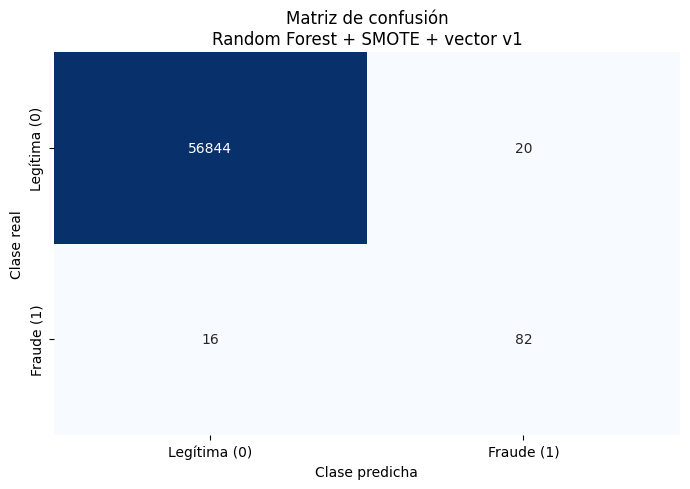

In [ ]:
# Visualizar la matriz de confusión de Random Forest + SMOTE + v1

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_rf_v1,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legítima (0)", "Fraude (1)"],
    yticklabels=["Legítima (0)", "Fraude (1)"]
)

plt.title(
    "Matriz de confusión\nRandom Forest + SMOTE + vector v1"
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()

In [ ]:
# Entrenar Regresión Logística con el vector v1

from sklearn.linear_model import LogisticRegression

regresion_logistica_v1 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

regresion_logistica_v1.fit(
    X_train_v1_smote,
    y_train_v1_smote
)

print("Regresión Logística con v1 entrenada correctamente.")

print(
    "Cantidad de variables utilizadas:",
    regresion_logistica_v1.n_features_in_
)

print(
    "Clases reconocidas por el modelo:",
    regresion_logistica_v1.classes_
)

print(
    "Iteraciones realizadas:",
    regresion_logistica_v1.n_iter_
)

Regresión Logística con v1 entrenada correctamente.
Cantidad de variables utilizadas: 18
Clases reconocidas por el modelo: [0 1]
Iteraciones realizadas: [83]


In [ ]:
# Generar predicciones con Regresión Logística usando v1

y_pred_regresion_v1 = regresion_logistica_v1.predict(
    X_test_v1
)

y_prob_regresion_v1 = regresion_logistica_v1.predict_proba(
    X_test_v1
)[:, 1]


# Verificar las predicciones

print(
    "Cantidad de predicciones:",
    len(y_pred_regresion_v1)
)

print("\nPrimeras 10 clases predichas:")
print(
    y_pred_regresion_v1[:10]
)

print("\nPrimeras 10 probabilidades de fraude:")
print(
    y_prob_regresion_v1[:10]
)

print("\nDistribución de clases predichas:")
print(
    pd.Series(
        y_pred_regresion_v1
    ).value_counts().sort_index()
)

Cantidad de predicciones: 56962

Primeras 10 clases predichas:
[0 0 1 0 1 0 0 0 0 0]

Primeras 10 probabilidades de fraude:
[0.10601346 0.03674464 0.77931526 0.02305692 0.83734828 0.13419109
 0.02267811 0.07276582 0.05082495 0.03359686]

Distribución de clases predichas:
0    55104
1     1858
Name: count, dtype: int64


In [ ]:
# Evaluar Regresión Logística + SMOTE usando el vector v1

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# Matriz de confusión

matriz_regresion_v1 = confusion_matrix(
    y_test,
    y_pred_regresion_v1
)

tn_reg_v1, fp_reg_v1, fn_reg_v1, tp_reg_v1 = (
    matriz_regresion_v1.ravel()
)


# Métricas

accuracy_reg_v1 = accuracy_score(
    y_test,
    y_pred_regresion_v1
)

precision_reg_v1 = precision_score(
    y_test,
    y_pred_regresion_v1,
    zero_division=0
)

recall_reg_v1 = recall_score(
    y_test,
    y_pred_regresion_v1,
    zero_division=0
)

especificidad_reg_v1 = tn_reg_v1 / (
    tn_reg_v1 + fp_reg_v1
)

f1_reg_v1 = f1_score(
    y_test,
    y_pred_regresion_v1,
    zero_division=0
)

roc_auc_reg_v1 = roc_auc_score(
    y_test,
    y_prob_regresion_v1
)

pr_auc_reg_v1 = average_precision_score(
    y_test,
    y_prob_regresion_v1
)


# Guardar resultados

metricas_regresion_v1 = pd.DataFrame({
    "Modelo": ["Regresión Logística + SMOTE + v1"],
    "Accuracy": [accuracy_reg_v1],
    "Precision": [precision_reg_v1],
    "Recall": [recall_reg_v1],
    "Especificidad": [especificidad_reg_v1],
    "F1_score": [f1_reg_v1],
    "ROC_AUC": [roc_auc_reg_v1],
    "PR_AUC": [pr_auc_reg_v1],
    "TN": [tn_reg_v1],
    "FP": [fp_reg_v1],
    "FN": [fn_reg_v1],
    "TP": [tp_reg_v1]
})


print("Matriz de confusión:")
print(matriz_regresion_v1)

display(metricas_regresion_v1)

Matriz de confusión:
[[55094  1770]
 [   10    88]]


,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Regresión Logística + SMOTE + v1,0.968751,0.047363,0.897959,0.968873,0.08998,0.95168,0.614031,55094,1770,10,88


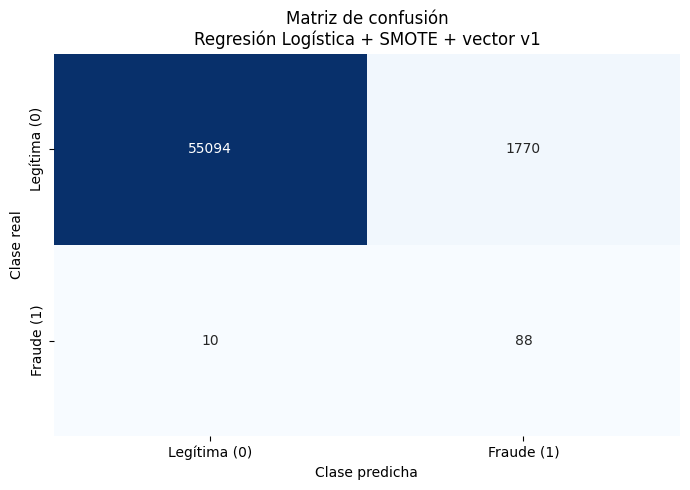

In [ ]:
# Visualizar matriz de confusión
# Regresión Logística + SMOTE + v1

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_regresion_v1,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legítima (0)", "Fraude (1)"],
    yticklabels=["Legítima (0)", "Fraude (1)"]
)

plt.title(
    "Matriz de confusión\n"
    "Regresión Logística + SMOTE + vector v1"
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()

In [ ]:
# Entrenar Árbol de Decisión con el vector v1

from sklearn.tree import DecisionTreeClassifier

arbol_decision_v1 = DecisionTreeClassifier(
    random_state=42
)

arbol_decision_v1.fit(
    X_train_v1_smote,
    y_train_v1_smote
)

print("Árbol de Decisión con v1 entrenado correctamente.")

print(
    "Cantidad de variables utilizadas:",
    arbol_decision_v1.n_features_in_
)

print(
    "Profundidad del árbol:",
    arbol_decision_v1.get_depth()
)

print(
    "Cantidad de hojas:",
    arbol_decision_v1.get_n_leaves()
)

Árbol de Decisión con v1 entrenado correctamente.
Cantidad de variables utilizadas: 18
Profundidad del árbol: 44
Cantidad de hojas: 1051


### Diagnóstico del Árbol de Decisión con `v1`

El árbol se entrena inicialmente sin restricciones de profundidad ni poda. Esta configuración permite observar su capacidad de ajuste, pero también puede generar sobreajuste. La comparación entre entrenamiento y prueba se utilizará para diagnosticarlo.


In [ ]:
# Generar predicciones con Árbol de Decisión usando v1

y_pred_arbol_v1 = arbol_decision_v1.predict(
    X_test_v1
)

y_prob_arbol_v1 = arbol_decision_v1.predict_proba(
    X_test_v1
)[:, 1]


# Verificar las predicciones

print(
    "Cantidad de predicciones:",
    len(y_pred_arbol_v1)
)

print("\nPrimeras 10 clases predichas:")
print(
    y_pred_arbol_v1[:10]
)

print("\nPrimeras 10 probabilidades de fraude:")
print(
    y_prob_arbol_v1[:10]
)

print("\nDistribución de clases predichas:")
print(
    pd.Series(
        y_pred_arbol_v1
    ).value_counts().sort_index()
)

Cantidad de predicciones: 56962

Primeras 10 clases predichas:
[0 0 0 0 0 0 0 0 0 0]

Primeras 10 probabilidades de fraude:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Distribución de clases predichas:
0    56739
1      223
Name: count, dtype: int64


La profundidad de 44 niveles, las 1.051 hojas y las probabilidades extremas generadas por hojas muy puras justifican examinar formalmente el desempeño dentro y fuera de muestra.


In [ ]:
# Evaluar Árbol de Decisión + SMOTE usando el vector v1

matriz_arbol_v1 = confusion_matrix(
    y_test,
    y_pred_arbol_v1
)

tn_arbol_v1, fp_arbol_v1, fn_arbol_v1, tp_arbol_v1 = (
    matriz_arbol_v1.ravel()
)


# Calcular métricas

accuracy_arbol_v1 = accuracy_score(
    y_test,
    y_pred_arbol_v1
)

precision_arbol_v1 = precision_score(
    y_test,
    y_pred_arbol_v1,
    zero_division=0
)

recall_arbol_v1 = recall_score(
    y_test,
    y_pred_arbol_v1,
    zero_division=0
)

especificidad_arbol_v1 = tn_arbol_v1 / (
    tn_arbol_v1 + fp_arbol_v1
)

f1_arbol_v1 = f1_score(
    y_test,
    y_pred_arbol_v1,
    zero_division=0
)

roc_auc_arbol_v1 = roc_auc_score(
    y_test,
    y_prob_arbol_v1
)

pr_auc_arbol_v1 = average_precision_score(
    y_test,
    y_prob_arbol_v1
)


# Guardar resultados

metricas_arbol_v1 = pd.DataFrame({
    "Modelo": ["Árbol de Decisión + SMOTE + v1"],
    "Accuracy": [accuracy_arbol_v1],
    "Precision": [precision_arbol_v1],
    "Recall": [recall_arbol_v1],
    "Especificidad": [especificidad_arbol_v1],
    "F1_score": [f1_arbol_v1],
    "ROC_AUC": [roc_auc_arbol_v1],
    "PR_AUC": [pr_auc_arbol_v1],
    "TN": [tn_arbol_v1],
    "FP": [fp_arbol_v1],
    "FN": [fn_arbol_v1],
    "TP": [tp_arbol_v1]
})


print("Matriz de confusión:")
print(matriz_arbol_v1)

display(metricas_arbol_v1)

Matriz de confusión:
[[56718   146]
 [   21    77]]


,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Árbol de Decisión + SMOTE + v1,0.997068,0.345291,0.785714,0.997432,0.479751,0.891573,0.271669,56718,146,21,77


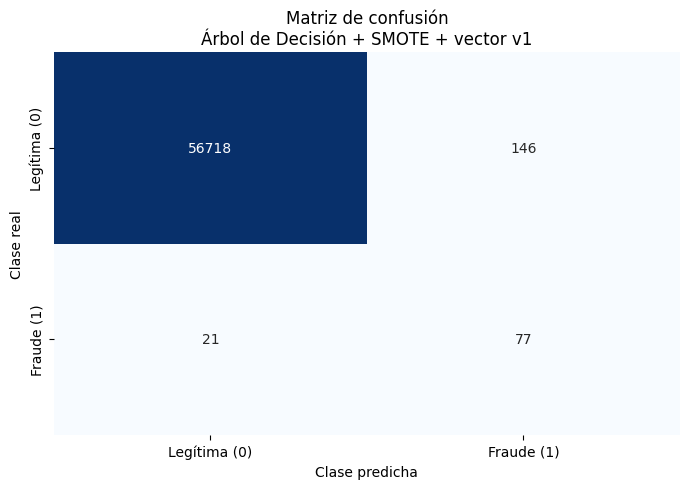

In [ ]:
# Visualizar matriz de confusión
# Árbol de Decisión + SMOTE + v1

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_arbol_v1,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legítima (0)", "Fraude (1)"],
    yticklabels=["Legítima (0)", "Fraude (1)"]
)

plt.title(
    "Matriz de confusión\n"
    "Árbol de Decisión + SMOTE + vector v1"
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()

In [ ]:
# Comparar los tres modelos entrenados con el vector v1

resultados_v1 = pd.concat(
    [
        metricas_regresion_v1,
        metricas_arbol_v1,
        metricas_random_forest_v1
    ],
    ignore_index=True
)


# Mantener un orden común de columnas

resultados_v1 = resultados_v1[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "Especificidad",
        "F1_score",
        "ROC_AUC",
        "PR_AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]


# Ordenar desde el mayor al menor F1-score

resultados_v1_ordenados = resultados_v1.sort_values(
    by="F1_score",
    ascending=False
).reset_index(drop=True)


display(
    resultados_v1_ordenados.round(6)
)

,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Random Forest + SMOTE + v1,0.999368,0.803922,0.836735,0.999648,0.820000,0.972400,0.859704,56844,20,16,82
1,Árbol de Decisión + SMOTE + v1,0.997068,0.345291,0.785714,0.997432,0.479751,0.891573,0.271669,56718,146,21,77
2,Regresión Logística + SMOTE + v1,0.968751,0.047363,0.897959,0.968873,0.089980,0.951680,0.614031,55094,1770,10,88


In [ ]:
# Diagnosticar posible sobreajuste del Árbol de Decisión con v1

# Predicciones sobre el entrenamiento original
y_pred_arbol_train_v1 = arbol_decision_v1.predict(
    X_train_v1
)

y_prob_arbol_train_v1 = arbol_decision_v1.predict_proba(
    X_train_v1
)[:, 1]


# Matriz de confusión en entrenamiento
matriz_arbol_train_v1 = confusion_matrix(
    y_train,
    y_pred_arbol_train_v1
)

tn_train_v1, fp_train_v1, fn_train_v1, tp_train_v1 = (
    matriz_arbol_train_v1.ravel()
)


# Métricas en entrenamiento
accuracy_arbol_train_v1 = accuracy_score(
    y_train,
    y_pred_arbol_train_v1
)

precision_arbol_train_v1 = precision_score(
    y_train,
    y_pred_arbol_train_v1,
    zero_division=0
)

recall_arbol_train_v1 = recall_score(
    y_train,
    y_pred_arbol_train_v1,
    zero_division=0
)

especificidad_arbol_train_v1 = tn_train_v1 / (
    tn_train_v1 + fp_train_v1
)

f1_arbol_train_v1 = f1_score(
    y_train,
    y_pred_arbol_train_v1,
    zero_division=0
)

roc_auc_arbol_train_v1 = roc_auc_score(
    y_train,
    y_prob_arbol_train_v1
)

pr_auc_arbol_train_v1 = average_precision_score(
    y_train,
    y_prob_arbol_train_v1
)


# Tabla comparativa entrenamiento versus prueba
diagnostico_sobreajuste_arbol_v1 = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento original",
        "Prueba"
    ],
    "Accuracy": [
        accuracy_arbol_train_v1,
        accuracy_arbol_v1
    ],
    "Precision": [
        precision_arbol_train_v1,
        precision_arbol_v1
    ],
    "Recall": [
        recall_arbol_train_v1,
        recall_arbol_v1
    ],
    "Especificidad": [
        especificidad_arbol_train_v1,
        especificidad_arbol_v1
    ],
    "F1_score": [
        f1_arbol_train_v1,
        f1_arbol_v1
    ],
    "ROC_AUC": [
        roc_auc_arbol_train_v1,
        roc_auc_arbol_v1
    ],
    "PR_AUC": [
        pr_auc_arbol_train_v1,
        pr_auc_arbol_v1
    ],
    "FP": [
        fp_train_v1,
        fp_arbol_v1
    ],
    "FN": [
        fn_train_v1,
        fn_arbol_v1
    ],
    "TP": [
        tp_train_v1,
        tp_arbol_v1
    ]
})

display(
    diagnostico_sobreajuste_arbol_v1.round(6)
)

,Conjunto,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,FP,FN,TP
0,Entrenamiento original,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0,394
1,Prueba,0.997068,0.345291,0.785714,0.997432,0.479751,0.891573,0.271669,146,21,77


El Árbol de Decisión sin restricciones alcanzó un rendimiento perfecto en entrenamiento, pero presentó una caída sustancial en Precision, Recall, F1-score y PR-AUC al evaluarse sobre el conjunto de prueba. Junto con su profundidad de 44 niveles y sus 1.051 hojas, esta diferencia constituye evidencia de sobreajuste.

### 4.5 Automatización de `v2`–`v5`

Una función común permite aplicar exactamente el mismo procedimiento a todos los modelos y vectores. Esto reduce repeticiones, limita errores de transcripción y facilita la comparación sistemática.


In [ ]:
# Crear una función para entrenar y evaluar cada modelo

from sklearn.base import clone


def evaluar_modelo_vector(
    nombre_vector,
    nombre_modelo,
    modelo_base,
    X_train_vector_smote,
    y_train_vector_smote,
    X_test_vector,
    y_test
):
    """
    Entrena un modelo con un vector de variables y devuelve:
    1. Sus métricas.
    2. Su matriz de confusión.
    3. El modelo entrenado.
    """

    # Crear una copia independiente del modelo
    modelo = clone(modelo_base)

    # Entrenar el modelo
    modelo.fit(
        X_train_vector_smote,
        y_train_vector_smote
    )

    # Generar predicciones
    y_pred = modelo.predict(
        X_test_vector
    )

    y_prob = modelo.predict_proba(
        X_test_vector
    )[:, 1]

    # Matriz de confusión
    matriz = confusion_matrix(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = matriz.ravel()

    # Guardar métricas
    resultado = {
        "Vector": nombre_vector,
        "Modelo": nombre_modelo,
        "N_variables": X_test_vector.shape[1],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Especificidad": tn / (tn + fp),
        "F1_score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR_AUC": average_precision_score(
            y_test,
            y_prob
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return resultado, matriz, modelo

#### Procedimiento automatizado

Luego de verificar manualmente el procedimiento con `v1`, se automatiza la evaluación de `v2`, `v3`, `v4` y `v5` mediante un ciclo. En cada vector se repiten las mismas etapas: selección de variables, aplicación de SMOTE solo al entrenamiento, entrenamiento de los tres modelos y cálculo de métricas.


La automatización mantiene la misma secuencia metodológica utilizada con `v1`: selección del vector, SMOTE aplicado solo al entrenamiento, ajuste del modelo y evaluación exclusiva sobre el test.


### 4.6 Auditoría de duplicados y solapamiento entre entrenamiento y prueba

El paper no documenta explícitamente un procedimiento de eliminación de filas completamente duplicadas. Por ello, la primera implementación utiliza el dataset tal como fue distribuido y luego evalúa su posible efecto.

Se detectaron 344 observaciones del conjunto de prueba con una copia exacta en entrenamiento, incluyendo 8 fraudes. Este solapamiento puede producir métricas optimistas. Posteriormente se realiza una extensión de robustez eliminando duplicados antes de crear una nueva partición.


In [ ]:
# Verificar observaciones idénticas entre entrenamiento y prueba

train_completo = X_train.copy()
train_completo["Class"] = y_train

test_completo = X_test.copy()
test_completo["Class"] = y_test


# Crear una identificación numérica para cada fila completa

hash_train = pd.util.hash_pandas_object(
    train_completo,
    index=False
)

hash_test = pd.util.hash_pandas_object(
    test_completo,
    index=False
)


# Identificar filas del test que también aparecen en entrenamiento

test_repetido_en_train = hash_test.isin(
    hash_train
)

cantidad_solapadas = test_repetido_en_train.sum()


print(
    "Observaciones del test con una copia exacta en entrenamiento:",
    cantidad_solapadas
)

print(
    "Porcentaje del test:",
    round(
        cantidad_solapadas / len(test_completo) * 100,
        6
    ),
    "%"
)

Observaciones del test con una copia exacta en entrenamiento: 344
Porcentaje del test: 0.603911 %


In [ ]:
# Analizar el solapamiento exacto entre entrenamiento y prueba

filas_test_solapadas = test_completo.loc[
    test_repetido_en_train
].copy()


# Contar observaciones solapadas por clase

solapamiento_por_clase = (
    filas_test_solapadas["Class"]
    .value_counts()
    .sort_index()
)


# Comparar con el total real del conjunto de prueba

total_test_por_clase = (
    test_completo["Class"]
    .value_counts()
    .sort_index()
)


resumen_solapamiento = pd.DataFrame({
    "Total_test": total_test_por_clase,
    "Filas_solapadas": solapamiento_por_clase
}).fillna(0)

resumen_solapamiento["Porcentaje_solapado"] = (
    resumen_solapamiento["Filas_solapadas"]
    / resumen_solapamiento["Total_test"]
    * 100
)


print("Solapamiento por clase:")

display(
    resumen_solapamiento.round(6)
)

Solapamiento por clase:


,Total_test,Filas_solapadas,Porcentaje_solapado
Class,,,
0,56864,336,0.590884
1,98,8,8.163265


v2 → SMOTE → Regresión Logística → Árbol → Random Forest
v3 → SMOTE → Regresión Logística → Árbol → Random Forest
v4 → SMOTE → Regresión Logística → Árbol → Random Forest
v5 → SMOTE → Regresión Logística → Árbol → Random Forest


In [ ]:
# Automatizar la evaluación de v2, v3, v4 y v5

modelos_base = {
    "Regresión Logística": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Árbol de Decisión": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}


# Contenedores para guardar resultados

resultados_automatizados = []
matrices_automatizadas = {}
modelos_entrenados = {}


# Recorrer los vectores restantes

for nombre_vector in ["v2", "v3", "v4", "v5"]:

    print(f"\nProcesando {nombre_vector}...")

    # Seleccionar las variables del vector actual

    variables_vector = vectores_ga_paper[nombre_vector]

    X_train_vector = X_train_scaled.loc[
        :,
        variables_vector
    ].copy()

    X_test_vector = X_test_scaled.loc[
        :,
        variables_vector
    ].copy()


    # Aplicar SMOTE solamente al entrenamiento
    # del vector actual

    smote_vector = SMOTE(
        random_state=42
    )

    X_train_vector_smote, y_train_vector_smote = (
        smote_vector.fit_resample(
            X_train_vector,
            y_train
        )
    )


    print(
        f"Variables: {len(variables_vector)} | "
        f"Entrenamiento después de SMOTE: "
        f"{X_train_vector_smote.shape}"
    )


    # Entrenar y evaluar los tres modelos

    for nombre_modelo, modelo_base in modelos_base.items():

        print(f"  Entrenando {nombre_modelo}...")

        resultado, matriz, modelo = evaluar_modelo_vector(
            nombre_vector=nombre_vector,
            nombre_modelo=nombre_modelo,
            modelo_base=modelo_base,
            X_train_vector_smote=X_train_vector_smote,
            y_train_vector_smote=y_train_vector_smote,
            X_test_vector=X_test_vector,
            y_test=y_test
        )


        # Guardar las métricas

        resultados_automatizados.append(
            resultado
        )


        # Guardar la matriz de confusión

        clave = (
            nombre_vector,
            nombre_modelo
        )

        matrices_automatizadas[clave] = matriz


        # Guardar el modelo entrenado

        modelos_entrenados[clave] = modelo


# Convertir todos los resultados en una tabla

resultados_vectores_v2_v5 = pd.DataFrame(
    resultados_automatizados
)


# Ordenar por vector y F1-score

resultados_vectores_v2_v5 = (
    resultados_vectores_v2_v5
    .sort_values(
        by=["Vector", "F1_score"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


print("\nAutomatización terminada.")

display(
    resultados_vectores_v2_v5.round(6)
)


Procesando v2...
Variables: 9 | Entrenamiento después de SMOTE: (454902, 9)
  Entrenando Regresión Logística...
  Entrenando Árbol de Decisión...
  Entrenando Random Forest...

Procesando v3...
Variables: 13 | Entrenamiento después de SMOTE: (454902, 13)
  Entrenando Regresión Logística...
  Entrenando Árbol de Decisión...
  Entrenando Random Forest...

Procesando v4...
Variables: 9 | Entrenamiento después de SMOTE: (454902, 9)
  Entrenando Regresión Logística...
  Entrenando Árbol de Decisión...
  Entrenando Random Forest...

Procesando v5...
Variables: 13 | Entrenamiento después de SMOTE: (454902, 13)
  Entrenando Regresión Logística...
  Entrenando Árbol de Decisión...
  Entrenando Random Forest...

Automatización terminada.


,Vector,Modelo,N_variables,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,v2,Random Forest,9,0.999350,0.801980,0.826531,0.999648,0.814070,0.967953,0.837298,56844,20,17,81
1,v2,Árbol de Decisión,9,0.995892,0.270270,0.816327,0.996201,0.406091,0.906264,0.220945,56648,216,18,80
2,v2,Regresión Logística,9,0.940504,0.022628,0.795918,0.940753,0.044006,0.874606,0.300929,53495,3369,20,78
3,v3,Random Forest,13,0.999386,0.800000,0.857143,0.999631,0.827586,0.965843,0.845939,56843,21,14,84
4,v3,Árbol de Decisión,13,0.996173,0.285714,0.816327,0.996483,0.423280,0.906405,0.233552,56664,200,18,80
5,v3,Regresión Logística,13,0.949686,0.029252,0.877551,0.949810,0.056616,0.958474,0.550260,54010,2854,12,86
6,v4,Random Forest,9,0.999087,0.701754,0.816327,0.999402,0.754717,0.961804,0.835999,56830,34,18,80
7,v4,Árbol de Decisión,9,0.995716,0.258278,0.795918,0.996061,0.390000,0.895990,0.205919,56640,224,20,78
8,v4,Regresión Logística,9,0.964819,0.039614,0.836735,0.965039,0.075646,0.911110,0.469470,54876,1988,16,82
9,v5,Random Forest,13,0.999315,0.797980,0.806122,0.999648,0.802030,0.967485,0.855289,56844,20,19,79


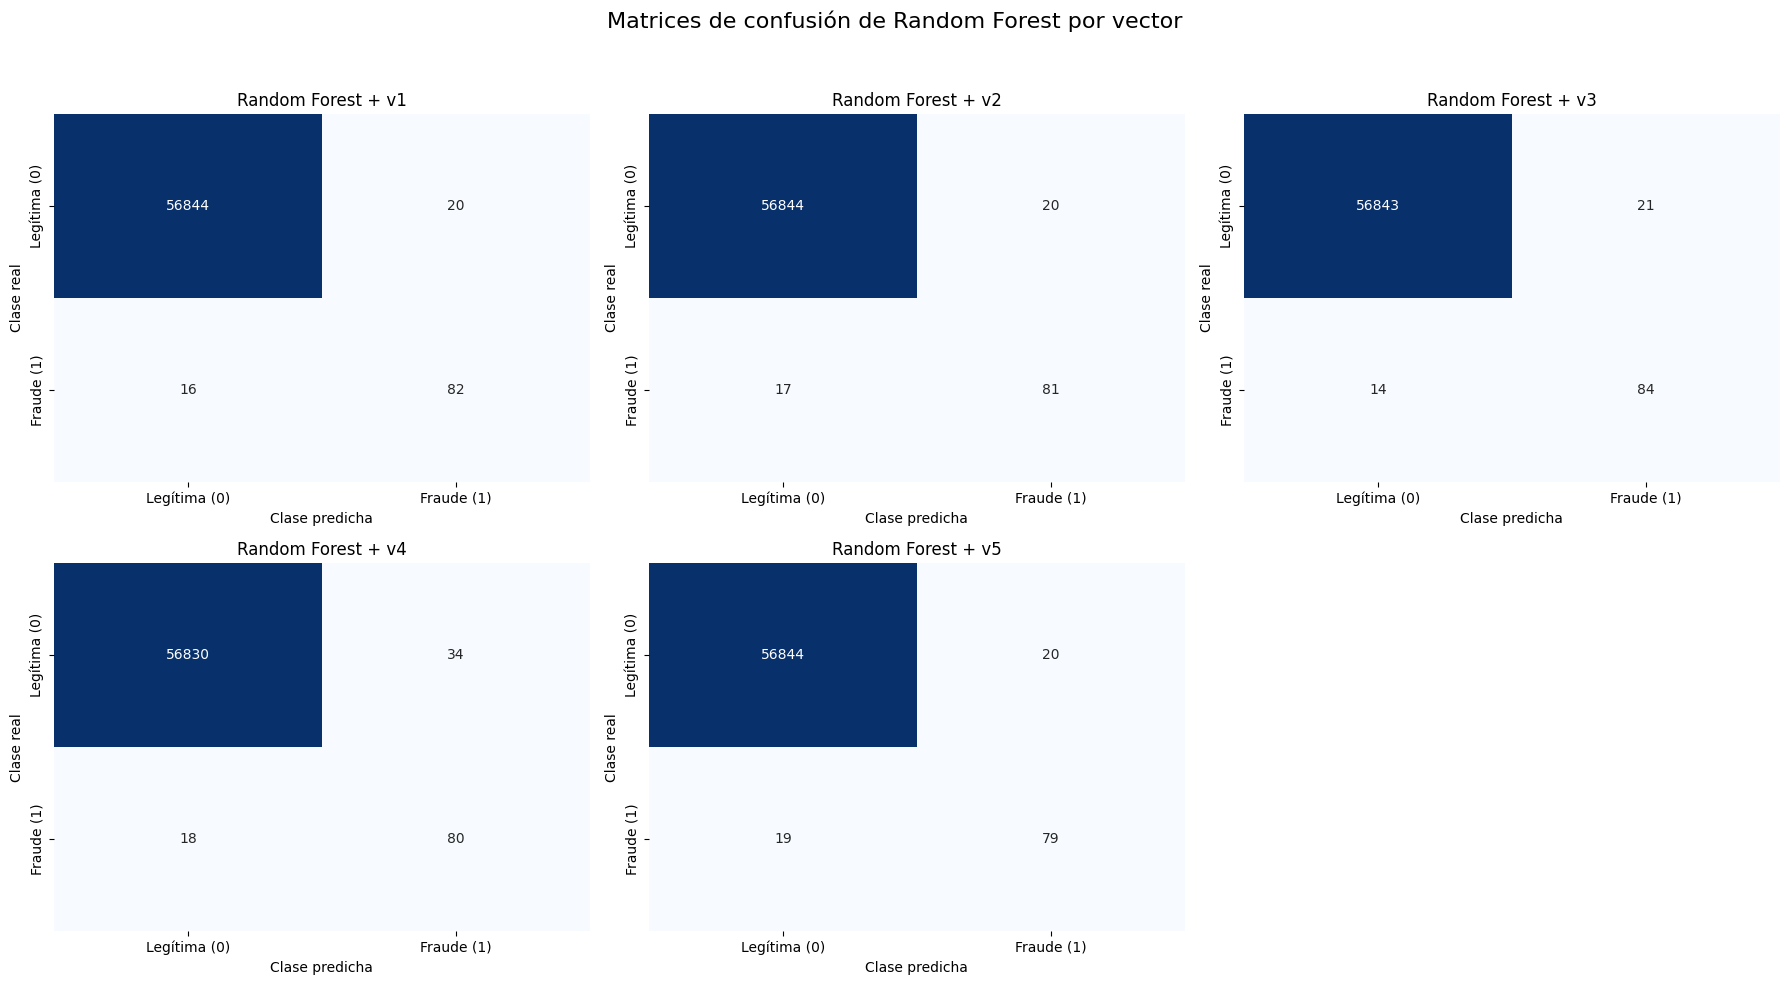

In [ ]:
# Reunir las matrices de Random Forest de v1 a v5

matrices_todos_vectores = {
    ("v1", "Random Forest"): matriz_rf_v1
}

matrices_todos_vectores.update(
    matrices_automatizadas
)


# Mostrar únicamente las matrices de Random Forest para v1–v5

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()


for eje, nombre_vector in zip(
    axes,
    ["v1", "v2", "v3", "v4", "v5"]
):

    matriz = matrices_todos_vectores[
        (nombre_vector, "Random Forest")
    ]

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[
            "Legítima (0)",
            "Fraude (1)"
        ],
        yticklabels=[
            "Legítima (0)",
            "Fraude (1)"
        ],
        ax=eje
    )

    eje.set_title(
        f"Random Forest + {nombre_vector}"
    )

    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")


# Ocultar el sexto panel, porque solo tenemos cinco vectores

axes[-1].axis("off")


fig.suptitle(
    "Matrices de confusión de Random Forest por vector",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

In [ ]:
# Integrar v1 con los resultados automatizados de v2 a v5

resultados_v1_final = resultados_v1.copy()

# Agregar información del vector
resultados_v1_final.insert(
    0,
    "Vector",
    "v1"
)

resultados_v1_final.insert(
    2,
    "N_variables",
    18
)

# Uniformar nombres de modelos
resultados_v1_final["Modelo"] = (
    resultados_v1_final["Modelo"]
    .str.replace(
        " + SMOTE + v1",
        "",
        regex=False
    )
)

# Orden común de columnas
columnas_finales = [
    "Vector",
    "Modelo",
    "N_variables",
    "Accuracy",
    "Precision",
    "Recall",
    "Especificidad",
    "F1_score",
    "ROC_AUC",
    "PR_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]

resultados_v1_final = resultados_v1_final[
    columnas_finales
]

# Unir las 15 combinaciones
resultados_15_modelos = pd.concat(
    [
        resultados_v1_final,
        resultados_vectores_v2_v5
    ],
    ignore_index=True
)

# Ordenar principalmente por F1-score
resultados_15_ordenados = (
    resultados_15_modelos
    .sort_values(
        by=["F1_score", "PR_AUC"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print(
    "Cantidad total de combinaciones:",
    len(resultados_15_ordenados)
)

display(
    resultados_15_ordenados.round(6)
)

Cantidad total de combinaciones: 15


,Vector,Modelo,N_variables,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,v3,Random Forest,13,0.999386,0.800000,0.857143,0.999631,0.827586,0.965843,0.845939,56843,21,14,84
1,v1,Random Forest,18,0.999368,0.803922,0.836735,0.999648,0.820000,0.972400,0.859704,56844,20,16,82
2,v2,Random Forest,9,0.999350,0.801980,0.826531,0.999648,0.814070,0.967953,0.837298,56844,20,17,81
3,v5,Random Forest,13,0.999315,0.797980,0.806122,0.999648,0.802030,0.967485,0.855289,56844,20,19,79
4,v4,Random Forest,9,0.999087,0.701754,0.816327,0.999402,0.754717,0.961804,0.835999,56830,34,18,80
5,v1,Árbol de Decisión,18,0.997068,0.345291,0.785714,0.997432,0.479751,0.891573,0.271669,56718,146,21,77
6,v3,Árbol de Decisión,13,0.996173,0.285714,0.816327,0.996483,0.423280,0.906405,0.233552,56664,200,18,80
7,v5,Árbol de Decisión,13,0.996190,0.278810,0.765306,0.996588,0.408719,0.880947,0.213779,56670,194,23,75
8,v2,Árbol de Decisión,9,0.995892,0.270270,0.816327,0.996201,0.406091,0.906264,0.220945,56648,216,18,80
9,v4,Árbol de Decisión,9,0.995716,0.258278,0.795918,0.996061,0.390000,0.895990,0.205919,56640,224,20,78


In [ ]:
# Comparar Random Forest con 30 variables
# frente a Random Forest con los cinco vectores

rf_30_variables = resultados_modelos[
    resultados_modelos["Modelo"].str.contains(
        "Random Forest",
        case=False,
        na=False
    )
].copy()


# Incorporar información equivalente

rf_30_variables.insert(
    0,
    "Vector",
    "Todas"
)

rf_30_variables.insert(
    2,
    "N_variables",
    30
)

rf_30_variables["Modelo"] = "Random Forest"


# Seleccionar los Random Forest de v1 a v5

rf_vectores = resultados_15_modelos[
    resultados_15_modelos["Modelo"] == "Random Forest"
].copy()


# Mantener las mismas columnas

columnas_comparacion_rf = [
    "Vector",
    "Modelo",
    "N_variables",
    "Accuracy",
    "Precision",
    "Recall",
    "Especificidad",
    "F1_score",
    "ROC_AUC",
    "PR_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]


# Unir y ordenar

comparacion_random_forest = pd.concat(
    [
        rf_30_variables[columnas_comparacion_rf],
        rf_vectores[columnas_comparacion_rf]
    ],
    ignore_index=True
)

comparacion_random_forest = (
    comparacion_random_forest
    .sort_values(
        by=["F1_score", "PR_AUC"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


display(
    comparacion_random_forest.round(6)
)

,Vector,Modelo,N_variables,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Todas,Random Forest,30,0.999473,0.854167,0.836735,0.999754,0.845361,0.963667,0.871521,56850,14,16,82
1,v3,Random Forest,13,0.999386,0.800000,0.857143,0.999631,0.827586,0.965843,0.845939,56843,21,14,84
2,v1,Random Forest,18,0.999368,0.803922,0.836735,0.999648,0.820000,0.972400,0.859704,56844,20,16,82
3,v2,Random Forest,9,0.999350,0.801980,0.826531,0.999648,0.814070,0.967953,0.837298,56844,20,17,81
4,v5,Random Forest,13,0.999315,0.797980,0.806122,0.999648,0.802030,0.967485,0.855289,56844,20,19,79
5,v4,Random Forest,9,0.999087,0.701754,0.816327,0.999402,0.754717,0.961804,0.835999,56830,34,18,80


### Conclusión de la evaluación con selección de variables

Random Forest entrenado con las 30 variables obtuvo el mejor desempeño global de la implementación inicial, con el mayor F1-score y PR-AUC. Entre los subconjuntos reportados por el algoritmo genético, el vector `v3` presentó el mejor F1-score y detectó 84 de los 98 fraudes utilizando 13 variables, aunque generó más falsos positivos que el modelo completo.

Estos resultados corresponden a la base distribuida originalmente. Como se detectó solapamiento de observaciones duplicadas entre entrenamiento y prueba —incluyendo 8 fraudes—, las métricas podrían estar sobreestimadas. La siguiente sección evalúa la robustez de los resultados mediante una partición construida después de eliminar filas completamente duplicadas.


## 5. Análisis de robustez: evaluación sin filas completamente duplicadas

El paper no especifica de forma suficiente cómo trató los duplicados del dataset. Por esta razón, esta segunda etapa se presenta como una extensión de robustez y no como una afirmación de que las filas repetidas sean necesariamente errores.

Se eliminan las filas completamente duplicadas antes de construir una nueva división entrenamiento–prueba. El objetivo es impedir que una observación idéntica aparezca en ambos conjuntos y comparar el desempeño con una evaluación sin solapamiento exacto.


### 5.1 Construcción de la base sin duplicados

Se eliminan únicamente filas completamente idénticas. Esta decisión no implica que toda repetición sea necesariamente un error transaccional; se utiliza como prueba de robustez para evitar copias exactas entre entrenamiento y prueba.


In [ ]:
# Crear una base limpia eliminando filas completamente duplicadas

df_clean = (
    df_raw
    .drop_duplicates()
    .reset_index(drop=True)
    .copy()
)


# Calcular cuántas observaciones fueron eliminadas

duplicados_eliminados = (
    len(df_raw) - len(df_clean)
)


# Comparar la distribución de clases antes y después

comparacion_clases = pd.DataFrame({
    "Base_original": (
        df_raw["Class"]
        .value_counts()
        .sort_index()
    ),
    "Base_limpia": (
        df_clean["Class"]
        .value_counts()
        .sort_index()
    )
})

comparacion_clases["Filas_eliminadas"] = (
    comparacion_clases["Base_original"]
    - comparacion_clases["Base_limpia"]
)


# Verificaciones

print("Dimensión de la base original:", df_raw.shape)
print("Dimensión de la base limpia:", df_clean.shape)

print(
    "Cantidad de duplicados eliminados:",
    duplicados_eliminados
)

print(
    "Duplicados restantes:",
    df_clean.duplicated().sum()
)

print("\nComparación por clase:")

display(comparacion_clases)

Dimensión de la base original: (284807, 31)
Dimensión de la base limpia: (283726, 31)
Cantidad de duplicados eliminados: 1081
Duplicados restantes: 0

Comparación por clase:


,Base_original,Base_limpia,Filas_eliminadas
Class,,,
0,284315,283253,1062
1,492,473,19


In [ ]:
# Verificar directamente los duplicados eliminados por clase

print(
    "Legítimas eliminadas:",
    int(
        comparacion_clases.loc[
            0,
            "Filas_eliminadas"
        ]
    )
)

print(
    "Fraudes eliminados:",
    int(
        comparacion_clases.loc[
            1,
            "Filas_eliminadas"
        ]
    )
)

print(
    "\nSuma total:",
    int(
        comparacion_clases[
            "Filas_eliminadas"
        ].sum()
    )
)

print("\nTabla completa:")
print(
    comparacion_clases.to_string()
)

Legítimas eliminadas: 1062
Fraudes eliminados: 19

Suma total: 1081

Tabla completa:
       Base_original  Base_limpia  Filas_eliminadas
Class                                              
0             284315       283253              1062
1                492          473                19


### 5.2 Nueva partición y control de solapamiento

Después de eliminar duplicados se construye una nueva división estratificada. Por esta razón, la cantidad de fraudes del test limpio no coincide exactamente con la del test original.


In [ ]:
# Separar variables predictoras y variable objetivo
# usando la base limpia

from sklearn.model_selection import train_test_split

X_clean = df_clean.drop(
    columns="Class"
)

y_clean = df_clean["Class"]


# Nueva partición estratificada 80 % entrenamiento
# y 20 % prueba

(
    X_train_clean,
    X_test_clean,
    y_train_clean,
    y_test_clean
) = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)


# Verificar dimensiones

print("Dimensiones:")

print(
    "X_train_clean:",
    X_train_clean.shape
)

print(
    "X_test_clean:",
    X_test_clean.shape
)

print(
    "y_train_clean:",
    y_train_clean.shape
)

print(
    "y_test_clean:",
    y_test_clean.shape
)


# Verificar distribución de clases

print("\nClases en entrenamiento:")

print(
    y_train_clean
    .value_counts()
    .sort_index()
)

print("\nPorcentaje en entrenamiento:")

print(
    y_train_clean
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
)


print("\nClases en prueba:")

print(
    y_test_clean
    .value_counts()
    .sort_index()
)

print("\nPorcentaje en prueba:")

print(
    y_test_clean
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
)

Dimensiones:
X_train_clean: (226980, 30)
X_test_clean: (56746, 30)
y_train_clean: (226980,)
y_test_clean: (56746,)

Clases en entrenamiento:
Class
0    226602
1       378
Name: count, dtype: int64

Porcentaje en entrenamiento:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Clases en prueba:
Class
0    56651
1       95
Name: count, dtype: int64

Porcentaje en prueba:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [ ]:
# Verificar que no exista solapamiento exacto
# entre entrenamiento y prueba de la base limpia

train_clean_completo = X_train_clean.copy()
train_clean_completo["Class"] = y_train_clean

test_clean_completo = X_test_clean.copy()
test_clean_completo["Class"] = y_test_clean


# Crear una huella digital para cada fila completa

hash_train_clean = pd.util.hash_pandas_object(
    train_clean_completo,
    index=False
)

hash_test_clean = pd.util.hash_pandas_object(
    test_clean_completo,
    index=False
)


# Verificar si alguna fila del test aparece también en train

test_clean_repetido_en_train = hash_test_clean.isin(
    hash_train_clean
)

cantidad_solapadas_clean = (
    test_clean_repetido_en_train.sum()
)


print(
    "Observaciones del test limpio con copia exacta en entrenamiento:",
    cantidad_solapadas_clean
)

print(
    "Porcentaje del test limpio:",
    round(
        cantidad_solapadas_clean
        / len(test_clean_completo)
        * 100,
        6
    ),
    "%"
)

Observaciones del test limpio con copia exacta en entrenamiento: 0
Porcentaje del test limpio: 0.0 %


### 5.3 Escalamiento y SMOTE en la extensión limpia

El escalador vuelve a ajustarse exclusivamente con el nuevo entrenamiento. SMOTE se aplica después del escalamiento y únicamente a ese conjunto. El test limpio permanece sin sobremuestreo.


In [ ]:
# Escalar las variables de la base limpia
# ajustando el escalador solo con entrenamiento

from sklearn.preprocessing import MinMaxScaler

scaler_clean = MinMaxScaler()


# Aprender mínimos y máximos del entrenamiento
# y transformar el entrenamiento

X_train_clean_scaled = pd.DataFrame(
    scaler_clean.fit_transform(
        X_train_clean
    ),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)


# Transformar el test usando exclusivamente
# los parámetros aprendidos en entrenamiento

X_test_clean_scaled = pd.DataFrame(
    scaler_clean.transform(
        X_test_clean
    ),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)


# Verificar dimensiones y valores

print("Dimensiones después del escalamiento:")

print(
    "X_train_clean_scaled:",
    X_train_clean_scaled.shape
)

print(
    "X_test_clean_scaled:",
    X_test_clean_scaled.shape
)


print("\nRango del entrenamiento:")

print(
    "Mínimo global:",
    X_train_clean_scaled.min().min()
)

print(
    "Máximo global:",
    X_train_clean_scaled.max().max()
)


print("\nPrimeras 5 filas escaladas:")

display(
    X_train_clean_scaled.head()
)

Dimensiones después del escalamiento:
X_train_clean_scaled: (226980, 30)
X_test_clean_scaled: (56746, 30)

Rango del entrenamiento:
Mínimo global: 0.0
Máximo global: 1.0

Primeras 5 filas escaladas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
225399,0.836549,0.996331,0.749062,0.732162,0.137658,0.494602,0.625105,0.536489,0.794612,0.419237,...,0.369810,0.559068,0.507730,0.669569,0.513845,0.565612,0.399449,0.651061,0.255955,0.001628
133746,0.467128,0.935953,0.784466,0.795986,0.250230,0.473699,0.529819,0.562153,0.793274,0.419102,...,0.373872,0.557628,0.465864,0.670244,0.489169,0.537884,0.381916,0.649457,0.258171,0.000356
185792,0.735659,0.990722,0.767482,0.733637,0.257662,0.497110,0.562855,0.559140,0.787319,0.472557,...,0.371607,0.566213,0.561152,0.664767,0.167389,0.583862,0.426716,0.651270,0.255886,0.000761
148925,0.528624,0.989065,0.770599,0.789478,0.423938,0.480472,0.571580,0.549989,0.787892,0.486254,...,0.371328,0.563718,0.542706,0.668019,0.516510,0.565977,0.423812,0.649458,0.256216,0.000880
18398,0.170853,0.981378,0.755431,0.794901,0.183324,0.461884,0.555919,0.543991,0.787669,0.390635,...,0.369209,0.555983,0.480341,0.669187,0.363706,0.574298,0.353637,0.651770,0.257338,0.001221


In [ ]:


# Aplicar SMOTE únicamente al entrenamiento limpio

from imblearn.over_sampling import SMOTE

smote_clean = SMOTE(
    random_state=42
)

X_train_clean_smote, y_train_clean_smote = (
    smote_clean.fit_resample(
        X_train_clean_scaled,
        y_train_clean
    )
)


# Asegurar estructura de DataFrame y Series

X_train_clean_smote = pd.DataFrame(
    X_train_clean_smote,
    columns=X_train_clean_scaled.columns
)

y_train_clean_smote = pd.Series(
    y_train_clean_smote,
    name="Class"
)


# Verificar antes y después

print("Antes de SMOTE:")

print(
    "X_train_clean_scaled:",
    X_train_clean_scaled.shape
)

print(
    y_train_clean
    .value_counts()
    .sort_index()
)


print("\nDespués de SMOTE:")

print(
    "X_train_clean_smote:",
    X_train_clean_smote.shape
)

print(
    y_train_clean_smote
    .value_counts()
    .sort_index()
)


print("\nConjunto de prueba sin modificar:")

print(
    "X_test_clean_scaled:",
    X_test_clean_scaled.shape
)

print(
    y_test_clean
    .value_counts()
    .sort_index()
)

Antes de SMOTE:
X_train_clean_scaled: (226980, 30)
Class
0    226602
1       378
Name: count, dtype: int64

Después de SMOTE:
X_train_clean_smote: (453204, 30)
Class
0    226602
1    226602
Name: count, dtype: int64

Conjunto de prueba sin modificar:
X_test_clean_scaled: (56746, 30)
Class
0    56651
1       95
Name: count, dtype: int64


### 5.4 Reentrenamiento de los modelos sobre la base sin duplicados

Se entrenan nuevamente Regresión Logística, Árbol de Decisión y Random Forest con las mismas configuraciones generales. La comparación con la primera implementación es informativa, pero no permite atribuir causalmente todas las variaciones a la eliminación de duplicados, porque la nueva partición contiene observaciones y una cantidad de fraudes ligeramente diferentes.


In [ ]:
# Entrenar y evaluar los tres modelos sobre la base limpia

modelos_base_clean = {
    "Regresión Logística": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Árbol de Decisión": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}


# Contenedores para guardar resultados

resultados_clean = []
matrices_clean = {}
modelos_clean = {}


# Entrenar y evaluar cada modelo

for nombre_modelo, modelo_base in modelos_base_clean.items():

    print(f"Entrenando {nombre_modelo}...")

    resultado, matriz, modelo = evaluar_modelo_vector(
        nombre_vector="Base limpia",
        nombre_modelo=nombre_modelo,
        modelo_base=modelo_base,
        X_train_vector_smote=X_train_clean_smote,
        y_train_vector_smote=y_train_clean_smote,
        X_test_vector=X_test_clean_scaled,
        y_test=y_test_clean
    )

    resultados_clean.append(resultado)

    matrices_clean[nombre_modelo] = matriz

    modelos_clean[nombre_modelo] = modelo

    print(f"{nombre_modelo} terminado.\n")


# Convertir los resultados en una tabla

resultados_modelos_clean = pd.DataFrame(
    resultados_clean
)


# Ordenar por F1-score

resultados_modelos_clean = (
    resultados_modelos_clean
    .sort_values(
        by=["F1_score", "PR_AUC"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


print("Entrenamiento finalizado.")

display(
    resultados_modelos_clean.round(6)
)

Entrenando Regresión Logística...
Regresión Logística terminado.

Entrenando Árbol de Decisión...
Árbol de Decisión terminado.

Entrenando Random Forest...
Random Forest terminado.

Entrenamiento finalizado.


,Vector,Modelo,N_variables,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Base limpia,Random Forest,30,0.999471,0.901235,0.768421,0.999859,0.829545,0.967319,0.823702,56643,8,22,73
1,Base limpia,Árbol de Decisión,30,0.996969,0.320930,0.726316,0.997423,0.445161,0.861869,0.233555,56505,146,26,69
2,Base limpia,Regresión Logística,30,0.976051,0.058042,0.873684,0.976223,0.108852,0.960898,0.634740,55304,1347,12,83


### 5.5 Comparación entre la primera implementación y la extensión limpia

La comparación permite observar la sensibilidad de los resultados al tratamiento de duplicados. Debe interpretarse con cautela: además de eliminar filas repetidas, se genera una nueva partición con observaciones diferentes.


In [ ]:
# Construir la comparación original vs. limpia desde los resultados calculados

resultados_originales = resultados_modelos.copy()

resultados_originales.insert(
    0,
    "Base",
    "Original con duplicados"
)

resultados_originales["Modelo"] = (
    resultados_originales["Modelo"]
    .str.replace(" + SMOTE", "", regex=False)
    .str.replace("logística", "Logística", regex=False)
    .str.replace("decisión", "Decisión", regex=False)
)


resultados_limpios = resultados_modelos_clean.copy()

resultados_limpios.insert(
    0,
    "Base",
    "Limpia sin duplicados"
)


columnas_comparacion = [
    "Base",
    "Modelo",
    "Accuracy",
    "Precision",
    "Recall",
    "Especificidad",
    "F1_score",
    "ROC_AUC",
    "PR_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]


comparacion_original_limpia = pd.concat(
    [
        resultados_originales[columnas_comparacion],
        resultados_limpios[columnas_comparacion]
    ],
    ignore_index=True
)


comparacion_original_limpia = (
    comparacion_original_limpia
    .sort_values(
        by=["Modelo", "Base"]
    )
    .reset_index(drop=True)
)


display(
    comparacion_original_limpia.round(6)
)


,Base,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Limpia sin duplicados,Random Forest,0.999471,0.901235,0.768421,0.999859,0.829545,0.967319,0.823702,56643,8,22,73
1,Original con duplicados,Random Forest,0.999473,0.854167,0.836735,0.999754,0.845361,0.963667,0.871521,56850,14,16,82
2,Limpia sin duplicados,Regresión Logística,0.976051,0.058042,0.873684,0.976223,0.108852,0.960898,0.634740,55304,1347,12,83
3,Original con duplicados,Regresión Logística,0.976037,0.061592,0.908163,0.976154,0.115360,0.974420,0.718247,55508,1356,9,89
4,Limpia sin duplicados,Árbol de Decisión,0.996969,0.320930,0.726316,0.997423,0.445161,0.861869,0.233555,56505,146,26,69
5,Original con duplicados,Árbol de Decisión,0.997367,0.370000,0.755102,0.997784,0.496644,0.876443,0.279809,56738,126,24,74


In [ ]:
# Recuperar el Árbol de Decisión entrenado
# sobre la base limpia con SMOTE

arbol_clean = modelos_clean[
    "Árbol de Decisión"
]


# Predicciones sobre el entrenamiento limpio original

y_pred_train_arbol_clean = arbol_clean.predict(
    X_train_clean_scaled
)

y_prob_train_arbol_clean = arbol_clean.predict_proba(
    X_train_clean_scaled
)[:, 1]


# Predicciones sobre el test limpio

y_pred_test_arbol_clean = arbol_clean.predict(
    X_test_clean_scaled
)

y_prob_test_arbol_clean = arbol_clean.predict_proba(
    X_test_clean_scaled
)[:, 1]


# Función breve para calcular métricas

def calcular_metricas_diagnostico(
    y_real,
    y_pred,
    y_prob,
    conjunto
):

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        y_pred
    ).ravel()

    return {
        "Conjunto": conjunto,
        "Accuracy": accuracy_score(
            y_real,
            y_pred
        ),
        "Precision": precision_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "Especificidad": tn / (tn + fp),
        "F1_score": f1_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_real,
            y_prob
        ),
        "PR_AUC": average_precision_score(
            y_real,
            y_prob
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# Construir tabla de diagnóstico

diagnostico_arbol_clean = pd.DataFrame([
    calcular_metricas_diagnostico(
        y_train_clean,
        y_pred_train_arbol_clean,
        y_prob_train_arbol_clean,
        "Entrenamiento limpio"
    ),

    calcular_metricas_diagnostico(
        y_test_clean,
        y_pred_test_arbol_clean,
        y_prob_test_arbol_clean,
        "Test limpio"
    )
])


# Complejidad del Árbol

print(
    "Profundidad del Árbol:",
    arbol_clean.get_depth()
)

print(
    "Cantidad de hojas:",
    arbol_clean.get_n_leaves()
)


display(
    diagnostico_arbol_clean.round(6)
)

Profundidad del Árbol: 42
Cantidad de hojas: 819


,Conjunto,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Entrenamiento limpio,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,226602,0,0,378
1,Test limpio,0.996969,0.32093,0.726316,0.997423,0.445161,0.861869,0.233555,56505,146,26,69


El Árbol de Decisión sin poda mantiene un ajuste perfecto sobre el entrenamiento limpio, pero su desempeño disminuye de forma importante en el test. La persistencia de esta brecha después de eliminar los duplicados indica que el sobreajuste se relaciona principalmente con la complejidad del árbol y no únicamente con el solapamiento entre conjuntos.


## 6. Modelo adicional propuesto: XGBoost

### 6.1 Justificación

XGBoost es un método de boosting de árboles que construye modelos secuencialmente para reducir la función de pérdida acumulada. Se elige porque captura relaciones no lineales e interacciones complejas en datos tabulares, constituye un benchmark frecuente en problemas financieros y no fue incluido entre los clasificadores del paper.

Para mantener una comparación homogénea, se entrena con la misma base limpia escalada y balanceada mediante SMOTE utilizada por los modelos anteriores. No se combina SMOTE con `scale_pos_weight`, evitando una doble compensación de la clase minoritaria.

### 6.2 Configuración

| Parámetro | Valor |
|---|---:|
| Número de árboles | 200 |
| Profundidad máxima | 4 |
| Learning rate | 0,1 |
| Subsample | 0,8 |
| Column sampling | 0,8 |
| Método de construcción | `hist` |
| Semilla | 42 |

La configuración busca capturar no linealidades controlando la complejidad y el costo computacional. No corresponde a una optimización exhaustiva.


In [ ]:
# Modelo adicional: XGBoost sobre la base limpia con SMOTE

from xgboost import XGBClassifier


modelo_xgb_clean = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)


print("Entrenando XGBoost...")

modelo_xgb_clean.fit(
    X_train_clean_smote,
    y_train_clean_smote
)

print("XGBoost terminado.")

Entrenando XGBoost...
XGBoost terminado.


In [ ]:
# Evaluar XGBoost sobre el conjunto de prueba limpio

y_pred_xgb_clean = modelo_xgb_clean.predict(
    X_test_clean_scaled
)

y_prob_xgb_clean = modelo_xgb_clean.predict_proba(
    X_test_clean_scaled
)[:, 1]


# Matriz de confusión

matriz_xgb_clean = confusion_matrix(
    y_test_clean,
    y_pred_xgb_clean
)

tn, fp, fn, tp = matriz_xgb_clean.ravel()


# Métricas

resultado_xgb_clean = pd.DataFrame(
    [
        {
            "Modelo": "XGBoost",
            "Accuracy": accuracy_score(
                y_test_clean,
                y_pred_xgb_clean
            ),
            "Precision": precision_score(
                y_test_clean,
                y_pred_xgb_clean,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test_clean,
                y_pred_xgb_clean,
                zero_division=0
            ),
            "Especificidad": tn / (tn + fp),
            "F1_score": f1_score(
                y_test_clean,
                y_pred_xgb_clean,
                zero_division=0
            ),
            "ROC_AUC": roc_auc_score(
                y_test_clean,
                y_prob_xgb_clean
            ),
            "PR_AUC": average_precision_score(
                y_test_clean,
                y_prob_xgb_clean
            ),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }
    ]
)


print("Matriz de confusión:")
print(matriz_xgb_clean)

display(resultado_xgb_clean)

Matriz de confusión:
[[56494   157]
 [   16    79]]


,Modelo,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,XGBoost,0.996951,0.334746,0.831579,0.997229,0.477341,0.974121,0.817909,56494,157,16,79


### Resultados de XGBoost

XGBoost alcanza un recall superior al de Random Forest, pero genera una cantidad considerablemente mayor de falsas alertas bajo el umbral estándar de 0,5. Random Forest mantiene un equilibrio operativo más favorable entre detección de fraude y precisión de las alertas.


## 7. Comparación final de resultados

Los cuatro modelos se comparan sobre el mismo test limpio y bajo el umbral estándar de clasificación de 0,5. La selección del modelo no se basa únicamente en Accuracy, sino principalmente en F1-score, PR-AUC, Recall, Precision y la cantidad de falsos positivos y falsos negativos.


In [ ]:
# Incorporar XGBoost a la comparación de modelos sobre la base limpia

resultado_xgb_clean_completo = resultado_xgb_clean.copy()

resultado_xgb_clean_completo["Vector"] = "Base limpia"
resultado_xgb_clean_completo["N_variables"] = (
    X_test_clean_scaled.shape[1]
)


# Ordenar sus columnas igual que en la tabla de los otros modelos

resultado_xgb_clean_completo = (
    resultado_xgb_clean_completo[
        resultados_modelos_clean.columns
    ]
)


# Unir los cuatro modelos

comparacion_modelos_clean = pd.concat(
    [
        resultados_modelos_clean,
        resultado_xgb_clean_completo
    ],
    ignore_index=True
)


# Ordenar principalmente por F1-score y luego por PR-AUC

comparacion_modelos_clean = (
    comparacion_modelos_clean
    .sort_values(
        by=["F1_score", "PR_AUC"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


print(
    "Comparación final de modelos sobre la base limpia:"
)

display(
    comparacion_modelos_clean.round(6)
)

Comparación final de modelos sobre la base limpia:


,Vector,Modelo,N_variables,Accuracy,Precision,Recall,Especificidad,F1_score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Base limpia,Random Forest,30,0.999471,0.901235,0.768421,0.999859,0.829545,0.967319,0.823702,56643,8,22,73
1,Base limpia,XGBoost,30,0.996951,0.334746,0.831579,0.997229,0.477341,0.974121,0.817909,56494,157,16,79
2,Base limpia,Árbol de Decisión,30,0.996969,0.320930,0.726316,0.997423,0.445161,0.861869,0.233555,56505,146,26,69
3,Base limpia,Regresión Logística,30,0.976051,0.058042,0.873684,0.976223,0.108852,0.960898,0.634740,55304,1347,12,83


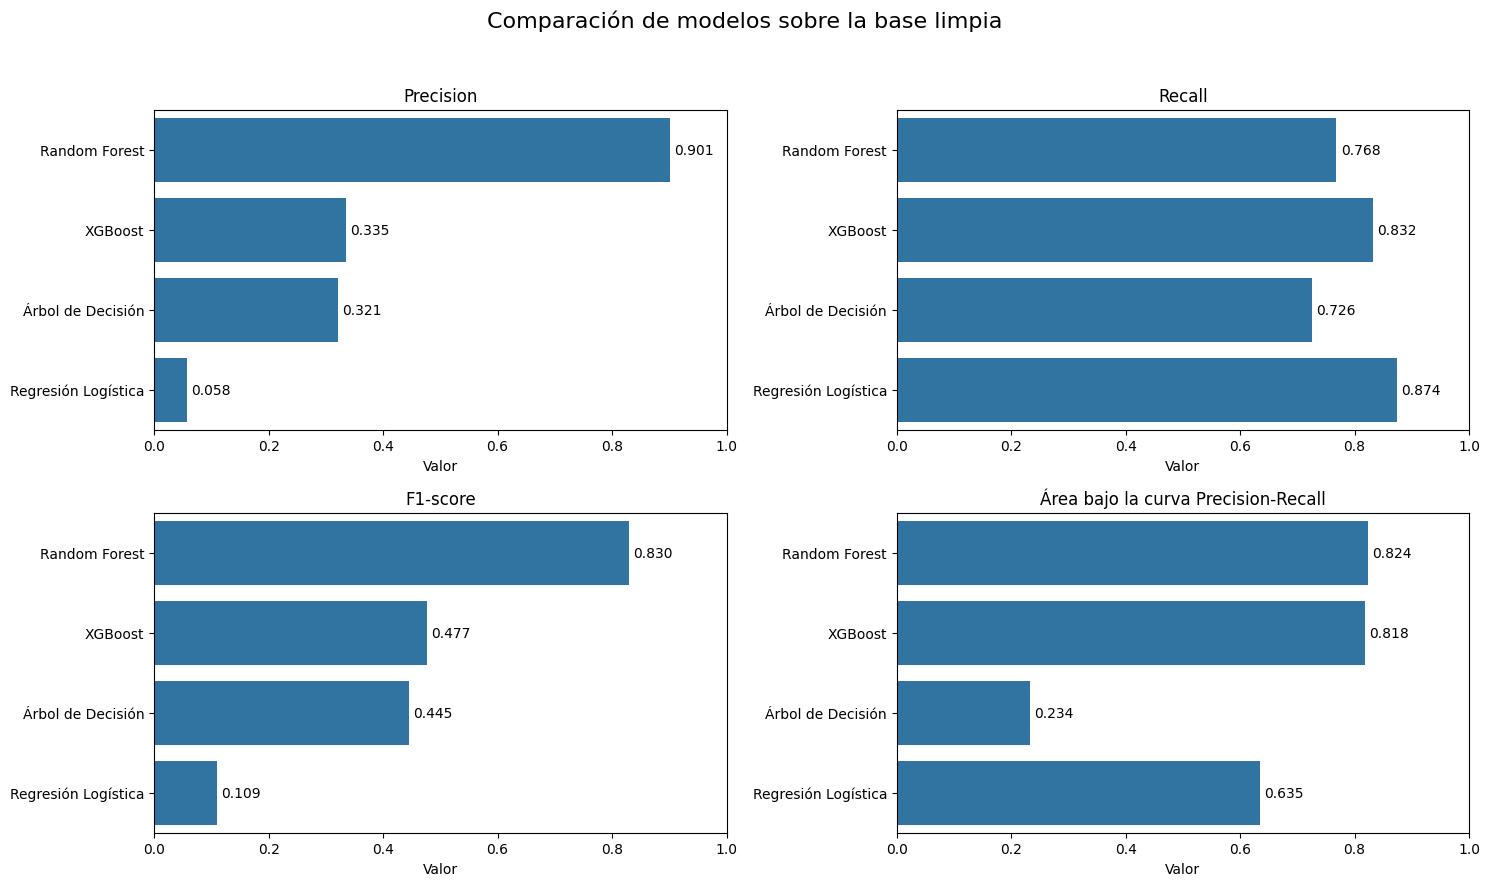

In [ ]:
# Comparación visual de las métricas más relevantes
# sobre la base limpia

metricas_comparacion = [
    "Precision",
    "Recall",
    "F1_score",
    "PR_AUC"
]

titulos_metricas = {
    "Precision": "Precision",
    "Recall": "Recall",
    "F1_score": "F1-score",
    "PR_AUC": "Área bajo la curva Precision-Recall"
}


# Mantener el orden definido por el F1-score

orden_modelos = (
    comparacion_modelos_clean["Modelo"]
    .tolist()
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 9)
)

axes = axes.flatten()


for eje, metrica in zip(
    axes,
    metricas_comparacion
):

    sns.barplot(
        data=comparacion_modelos_clean,
        x=metrica,
        y="Modelo",
        order=orden_modelos,
        ax=eje
    )

    eje.set_title(
        titulos_metricas[metrica]
    )

    eje.set_xlabel("Valor")
    eje.set_ylabel("")
    eje.set_xlim(0, 1)

    for contenedor in eje.containers:
        eje.bar_label(
            contenedor,
            fmt="%.3f",
            padding=3
        )


fig.suptitle(
    "Comparación de modelos sobre la base limpia",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

## 8. Discusión, conclusiones y limitaciones

### 8.1 Lectura integrada de los resultados

Con la base limpia, Random Forest presenta el mejor equilibrio global: combina alta Precision, un F1-score de aproximadamente 0,83, un PR-AUC cercano a 0,82 y solo ocho falsos positivos. XGBoost detecta más fraudes que Random Forest, pero genera muchas más falsas alarmas bajo el umbral estándar. La Regresión Logística obtiene el mayor Recall, aunque su baja Precision implica un costo operativo elevado. El Árbol de Decisión muestra una brecha marcada entre entrenamiento y prueba, consistente con sobreajuste.

### 8.2 Discusión económica y estadística de los resultados

La evaluación de los modelos no debe limitarse a identificar cuál obtiene la mayor cantidad de predicciones correctas. En un problema de detección de fraude, los errores tienen consecuencias distintas: un falso negativo corresponde a un fraude que el sistema no detecta, mientras que un falso positivo corresponde a una transacción legítima marcada incorrectamente como fraudulenta.

Random Forest detecta 73 de los 95 fraudes presentes en el conjunto de prueba y genera solo 8 falsas alertas. Esto se refleja en una precisión de 90,12 %, lo que significa que la gran mayoría de las transacciones clasificadas como fraude efectivamente pertenecen a esa categoría. Su recall es de 76,84 %, por lo que deja sin detectar 22 fraudes.

XGBoost detecta 79 de los 95 fraudes, es decir, identifica 6 fraudes adicionales respecto de Random Forest. Sin embargo, genera 157 falsas alertas, 149 más que Random Forest. Como resultado, su precisión disminuye a 33,47 %, aunque alcanza un recall mayor, de 83,16 %.

Desde una perspectiva operativa, esta diferencia es relevante. Random Forest genera 81 alertas en total, de las cuales 73 corresponden efectivamente a fraude. XGBoost genera 236 alertas, pero solo 79 son fraudes reales. Por tanto, el aumento en la detección obtenido por XGBoost exige revisar una cantidad considerablemente mayor de transacciones legítimas.

XGBoost presenta una elevada capacidad de discriminación general, reflejada en su ROC-AUC. Sin embargo, bajo el umbral de clasificación estándar de 0,5, su desempeño operativo se ve afectado por la alta cantidad de falsos positivos. Random Forest, en cambio, obtiene el mayor F1-score y PR-AUC, manteniendo un mejor equilibrio entre detección de fraudes y calidad de las alertas.

En ausencia de información sobre el costo monetario asociado a cada tipo de error, Random Forest fue el modelo con mejor equilibrio operativo entre los evaluados, debido a su alta precisión, su F1-score y su baja cantidad de falsos positivos. Esta elección no implica que los falsos negativos sean menos importantes, sino que el modelo entrega una relación más favorable entre fraudes detectados y falsas alarmas. XGBoost podría ser preferible en un contexto donde el costo de dejar pasar un fraude fuera extremadamente alto y existiera suficiente capacidad operativa para revisar un mayor número de alertas.

La recomendación se basa principalmente en los resultados obtenidos con la base sin filas completamente duplicadas. En la implementación inicial se identificó solapamiento de observaciones idénticas entre los conjuntos de entrenamiento y prueba, lo que podía favorecer una evaluación optimista al permitir que el modelo reconociera transacciones previamente observadas. Este fenómeno corresponde a contaminación entre conjuntos y no debe confundirse directamente con sobreajuste. Después de eliminar los duplicados antes de realizar la partición, Random Forest mantuvo el mejor equilibrio entre precisión, recall, F1-score y cantidad de falsas alertas, lo que fortalece la robustez de la recomendación.


### 8.3 Comparación con el paper original

El artículo de Ileberi, Sun y Wang (2022) reporta como mejor resultado la combinación Random Forest con el vector `v5`. En nuestro análisis, Random Forest también presenta el mejor desempeño general frente a Regresión Logística y Árbol de Decisión. Sin embargo, el orden de los vectores no se reproduce de forma idéntica: `v3` obtiene el mejor resultado entre los subconjuntos seleccionados, mientras que el modelo que utiliza las 30 variables alcanza el mayor F1-score global.

La siguiente tabla compara el resultado principal del artículo con las configuraciones más relevantes obtenidas en este trabajo.

In [ ]:
# Comparación entre el resultado principal del paper
# y los resultados obtenidos con Random Forest

tabla_comparacion_paper = pd.DataFrame([
    {
        "Fuente": "Paper",
        "Configuración": "Random Forest + v5",
        "N_variables": 13,
        "Accuracy": 0.9998,
        "Precision": 0.9534,
        "Recall": 0.7256,
        "F1_score": 0.8241
    },
    {
        "Fuente": "Este trabajo",
        "Configuración": "Random Forest + v5",
        "N_variables": 13,
        "Accuracy": 0.999315,
        "Precision": 0.797980,
        "Recall": 0.806122,
        "F1_score": 0.802030
    },
    {
        "Fuente": "Este trabajo",
        "Configuración": "Random Forest + v3",
        "N_variables": 13,
        "Accuracy": 0.999386,
        "Precision": 0.800000,
        "Recall": 0.857143,
        "F1_score": 0.827586
    },
    {
        "Fuente": "Este trabajo",
        "Configuración": "Random Forest + todas las variables",
        "N_variables": 30,
        "Accuracy": 0.999473,
        "Precision": 0.854167,
        "Recall": 0.836735,
        "F1_score": 0.845361
    }
])

display(
    tabla_comparacion_paper.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1_score": "{:.2%}"
    })
)

,Fuente,Configuración,N_variables,Accuracy,Precision,Recall,F1_score
0,Paper,Random Forest + v5,13,99.98%,95.34%,72.56%,82.41%
1,Este trabajo,Random Forest + v5,13,99.93%,79.80%,80.61%,80.20%
2,Este trabajo,Random Forest + v3,13,99.94%,80.00%,85.71%,82.76%
3,Este trabajo,Random Forest + todas las variables,30,99.95%,85.42%,83.67%,84.54%


Los resultados reproducen la conclusión general del paper respecto de la superioridad de Random Forest, aunque no replican exactamente la elección de `v5` como mejor vector.

Entre los subconjuntos de variables seleccionados por el algoritmo genético, `v3` presenta el mejor desempeño. Este vector detecta 84 de los 98 fraudes del conjunto de prueba, superando los 79 detectados por `v5`, y alcanza el mayor F1-score entre los vectores evaluados. Esto muestra que es posible conservar un desempeño competitivo utilizando solo 13 variables.

Sin embargo, el modelo Random Forest entrenado con las 30 variables obtiene el mejor resultado global. Presenta el mayor F1-score, la mejor precisión y una menor cantidad de falsas alertas, por lo que ofrece el equilibrio más favorable entre detección de fraude y costo operativo.

La diferencia respecto del paper no implica necesariamente una contradicción con sus resultados. El desempeño puede variar según la partición de entrenamiento y prueba, las semillas aleatorias, los hiperparámetros, el tratamiento de observaciones duplicadas y otros detalles de implementación. En consecuencia, la réplica coincide cualitativamente con el artículo en que Random Forest es el modelo más competitivo, pero no reproduce la superioridad específica del vector `v5`.

### 8.4 Conclusiones

Los resultados coinciden con el hallazgo general del artículo: Random Forest fue el clasificador más competitivo. Entre los subconjuntos de variables, `v3` obtuvo el mejor F1-score y detectó 84 de los 98 fraudes utilizando 13 variables. Sin embargo, Random Forest con las 30 variables alcanzó el mejor resultado global en la implementación inicial.

En la base sin filas duplicadas, Random Forest mantuvo el mejor equilibrio operativo entre los modelos evaluados, con 73 fraudes detectados y solo 8 falsas alertas. XGBoost identificó 6 fraudes adicionales, pero elevó las falsas alertas a 157. Por ello, la elección final depende del costo relativo de ambos tipos de error y de la capacidad institucional para revisar alertas.

El análisis también confirma la importancia de aplicar las transformaciones y SMOTE únicamente sobre el entrenamiento, controlar el solapamiento entre conjuntos y utilizar métricas apropiadas para clases altamente desbalanceadas.



### 8.5 Limitaciones

1. Los subconjuntos de variables seleccionados mediante algoritmo genético se obtuvieron directamente del artículo, por lo que no se evaluó la estabilidad del proceso de selección ante otras semillas o configuraciones.

2. El conjunto de datos corresponde a transacciones realizadas durante aproximadamente dos días de septiembre de 2013. Esto limita la capacidad de generalizar los resultados a otros periodos, instituciones y patrones actuales de fraude.

3. Las variables `V1`–`V28` se encuentran anonimizadas mediante análisis de componentes principales, lo que impide interpretar directamente su significado económico y transaccional.

4. SMOTE genera observaciones sintéticas para balancear la clase minoritaria. Aunque facilita el entrenamiento, estas observaciones no necesariamente representan transacciones reales.

5. No se realizó una búsqueda exhaustiva de hiperparámetros ni validación cruzada. Por tanto, los resultados corresponden a las configuraciones evaluadas y no garantizan el desempeño máximo posible de cada algoritmo.

6. Los modelos fueron comparados utilizando un umbral de clasificación de 0,5 y sin una función monetaria que valore el costo relativo de falsos positivos y falsos negativos. En consecuencia, la recomendación de Random Forest depende del criterio operativo utilizado.

7. Se identificaron 1.081 filas completamente duplicadas, de las cuales 1.062 correspondían a transacciones legítimas y 19 a fraudes. Debido a que el conjunto de datos no incluye un identificador único de transacción, no es posible determinar si estas observaciones representan registros repetidos por error o transacciones distintas con características idénticas. Por esta razón, la eliminación de duplicados se utilizó como análisis de robustez y no como una corrección indiscutible de la base.

### 8.6 Posibles extensiones

- Validación cruzada estratificada dentro del entrenamiento.
- Optimización del umbral con un conjunto de validación independiente.
- Calibración de probabilidades.
- Evaluación mediante una matriz de costos definida por la institución.
- Análisis temporal fuera de muestra con datos de periodos posteriores.
- Reejecución completa del Genetic Algorithm con parámetros documentados.
- Técnicas de interpretabilidad para XGBoost y Random Forest.


## 9. Reproducibilidad y repositorio

El proyecto se publicará en un repositorio público de GitHub para facilitar la revisión, ejecución y reproducción del análisis.

### 9.1 Estructura del repositorio

```text
credit-card-fraud-detection-ml/
├── README.md
├── requirements.txt
└── credit_card_fraud_detection_ml.ipynb
```

El notebook contiene el análisis completo, desde la obtención y exploración de los datos hasta la evaluación y comparación de los modelos. El archivo `README.md` resume el proyecto y explica su ejecución, mientras que `requirements.txt` registra las bibliotecas necesarias.

### 9.2 Fuente y obtención de los datos

El conjunto de datos **Credit Card Fraud Detection** se encuentra disponible públicamente en Kaggle. Debido a su tamaño, el archivo `creditcard.csv` no se incluye en el repositorio. El notebook lo obtiene automáticamente mediante la biblioteca `kagglehub`.

### 9.3 Instrucciones de ejecución

1. Descargar o clonar el repositorio.
2. Instalar las dependencias indicadas en `requirements.txt`.
3. Abrir `credit_card_fraud_detection_ml.ipynb`.
4. Ejecutar todas las celdas en orden.

Las semillas aleatorias utilizadas en la partición de datos, SMOTE y los modelos reducen la variabilidad entre ejecuciones y facilitan la comparación de resultados.



## 10. Referencias

- Ileberi, E., Sun, Y., & Wang, Z. (2022). *A machine learning based credit card fraud detection using the GA algorithm for feature selection*. Journal of Big Data, 9, Article 24.

- Machine Learning Group – ULB. (s. f.). *Credit Card Fraud Detection* [Conjunto de datos]. Kaggle.

- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic minority over-sampling technique*. Journal of Artificial Intelligence Research, 16, 321–357.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.

- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). *Imbalanced-learn: A Python toolbox to tackle the curse of imbalanced datasets in machine learning*. Journal of Machine Learning Research, 18(17), 1–5.

- Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785–794.

- OpenAI. (2026). *ChatGPT*: utilizado para organizar el cuaderno, iterar la redacción y revisar la secuencia de ejecución.